# AgriCast360 - Comprehensive Prediction Model Building
## Weather-Driven Crop Price & Yield Forecasting

**Objective**: Build accurate prediction models for:
1. **Crop Prices** by Mandi (historical data + weather)
2. **Yield & Supply** (historical data + weather driven)

**Models to Build**:
- Linear Regression (Baseline)
- Random Forest Regressor
- XGBoost (Gradient Boosting with optimized parameters)
- Neural Network (Deep Learning)
- Ensemble Methods (Stacking & Voting)

**Evaluation Metrics**:
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- MAPE (Mean Absolute Percentage Error)

In [2]:
# CELL 1: SETUP & IMPORTS
# Import all necessary libraries and configurations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from datetime import datetime
import pickle
import json

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, VotingRegressor, StackingRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Advanced Libraries
import xgboost as xgb
from tensorflow import keras
from tensorflow.keras import layers, callbacks
import tensorflow as tf

# Visualization
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 6)
pd.set_option('display.max_columns', None)

# Configuration
ROOT_FOLDER = Path(r"D:\CUDA_Experiments\Git_HUB\Machine-Learning\AgriCast360\AgriCast360_V2")
EDA_RESULTS = ROOT_FOLDER / "EDA_Results"
PROCESSED_DATA = ROOT_FOLDER / "Processed_Data"
MODELS_FOLDER = ROOT_FOLDER / "Models"
MODELS_FOLDER.mkdir(exist_ok=True)
RESULTS_FOLDER = ROOT_FOLDER / "Model_Results"
RESULTS_FOLDER.mkdir(exist_ok=True)

print("="*80)
print("✅ ALL LIBRARIES IMPORTED SUCCESSFULLY")
print("="*80)
print(f"\n📁 Project Folders:")
print(f"   Root: {ROOT_FOLDER}")
print(f"   EDA Results: {EDA_RESULTS}")
print(f"   Processed Data: {PROCESSED_DATA}")
print(f"   Models: {MODELS_FOLDER}")
print(f"   Results: {RESULTS_FOLDER}")


✅ ALL LIBRARIES IMPORTED SUCCESSFULLY

📁 Project Folders:
   Root: D:\CUDA_Experiments\Git_HUB\Machine-Learning\AgriCast360\AgriCast360_V2
   EDA Results: D:\CUDA_Experiments\Git_HUB\Machine-Learning\AgriCast360\AgriCast360_V2\EDA_Results
   Processed Data: D:\CUDA_Experiments\Git_HUB\Machine-Learning\AgriCast360\AgriCast360_V2\Processed_Data
   Models: D:\CUDA_Experiments\Git_HUB\Machine-Learning\AgriCast360\AgriCast360_V2\Models
   Results: D:\CUDA_Experiments\Git_HUB\Machine-Learning\AgriCast360\AgriCast360_V2\Model_Results
✅ ALL LIBRARIES IMPORTED SUCCESSFULLY

📁 Project Folders:
   Root: D:\CUDA_Experiments\Git_HUB\Machine-Learning\AgriCast360\AgriCast360_V2
   EDA Results: D:\CUDA_Experiments\Git_HUB\Machine-Learning\AgriCast360\AgriCast360_V2\EDA_Results
   Processed Data: D:\CUDA_Experiments\Git_HUB\Machine-Learning\AgriCast360\AgriCast360_V2\Processed_Data
   Models: D:\CUDA_Experiments\Git_HUB\Machine-Learning\AgriCast360\AgriCast360_V2\Models
   Results: D:\CUDA_Experiments

In [3]:
# CELL 2: DATA LOADING & EXPLORATION
# Load combined Mandi and Weather data

print("="*80)
print("LOADING DATA FROM EDA RESULTS")
print("="*80)

# Load combined Mandi data
mandi_data_path = EDA_RESULTS / "Mandi" / "Overall" / "combined_mandi_data.csv"
mandi_data = pd.read_csv(mandi_data_path)

print(f"\n✅ Mandi Data Loaded")
print(f"   Shape: {mandi_data.shape}")
print(f"   Columns: {mandi_data.columns.tolist()}")
print(f"   Date Range: {mandi_data.columns}")
print(f"\n   First Few Rows:")
print(mandi_data.head())

# Load combined Weather data
weather_data_path = EDA_RESULTS / "Weather" / "Overall" / "combined_weather_data.csv"
weather_data = pd.read_csv(weather_data_path)

print(f"\n✅ Weather Data Loaded")
print(f"   Shape: {weather_data.shape}")
print(f"   Columns: {weather_data.columns.tolist()}")
print(f"\n   First Few Rows:")
print(weather_data.head())

# Check data info
print("\n" + "="*80)
print("DATA EXPLORATION")
print("="*80)

print(f"\nMandi Data Info:")
print(f"   Total Records: {len(mandi_data):,}")
print(f"   Total Columns: {len(mandi_data.columns)}")
print(f"   Missing Values: {mandi_data.isnull().sum().sum()}")
print(f"   Numeric Columns: {len(mandi_data.select_dtypes(include=[np.number]).columns)}")

print(f"\nWeather Data Info:")
print(f"   Total Records: {len(weather_data):,}")
print(f"   Total Columns: {len(weather_data.columns)}")
print(f"   Missing Values: {weather_data.isnull().sum().sum()}")
print(f"   Numeric Columns: {len(weather_data.select_dtypes(include=[np.number]).columns)}")

# Data statistics
print(f"\nMandi Data Statistics:")
print(mandi_data.describe())

print(f"\nWeather Data Statistics:")
print(weather_data.describe())

LOADING DATA FROM EDA RESULTS

✅ Mandi Data Loaded
   Shape: (84549, 11)
   Columns: ['State', 'District', 'Market', 'Commodity', 'Variety', 'Arrival_Date', 'Min_Price', 'Max_Price', 'Modal_Price', 'Commodity_Code', 'Source_Mandi']
   Date Range: Index(['State', 'District', 'Market', 'Commodity', 'Variety', 'Arrival_Date',
       'Min_Price', 'Max_Price', 'Modal_Price', 'Commodity_Code',
       'Source_Mandi'],
      dtype='object')

   First Few Rows:
     State   District              Market Commodity Variety Arrival_Date  \
0  Gujarat  Ahmedabad  Ahmedabad (Vasana)   Cabbage   Other   2024-07-08   
1  Gujarat  Ahmedabad  Ahmedabad (Vasana)   Cabbage   Other   2024-07-10   
2  Gujarat  Ahmedabad  Ahmedabad (Vasana)   Cabbage   Other   2024-07-13   
3  Gujarat  Ahmedabad  Ahmedabad (Vasana)   Cabbage   Other   2024-07-26   
4  Gujarat  Ahmedabad  Ahmedabad (Vasana)   Cabbage   Other   2024-07-30   

   Min_Price  Max_Price  Modal_Price  Commodity_Code Source_Mandi  
0       1200      

In [4]:
# CELL 3: DATA PREPARATION & PREPROCESSING
# Prepare data for modeling - handle missing values, merge datasets, feature engineering

print("="*80)
print("DATA PREPARATION & PREPROCESSING")
print("="*80)

# Prepare Mandi data
print("\n1. MANDI DATA PREPARATION")
print("-"*80)

# Identify target and feature columns in Mandi data
numeric_mandi = mandi_data.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns in Mandi data: {numeric_mandi}")

# Assuming 'Price' or similar column is target - let's identify it
price_cols = [col for col in numeric_mandi if 'price' in col.lower() or 'cost' in col.lower() or 'rate' in col.lower()]
print(f"Potential target columns: {price_cols}")

# If no price column found, use first numeric column as target
if price_cols:
    target_mandi = price_cols[0]
else:
    target_mandi = numeric_mandi[0] if numeric_mandi else None

print(f"Selected Target Column: {target_mandi}")

# Handle missing values in Mandi data
mandi_data_clean = mandi_data.copy()
missing_threshold = 0.5  # Drop columns with >50% missing

cols_to_drop = [col for col in mandi_data_clean.columns 
                if (mandi_data_clean[col].isnull().sum() / len(mandi_data_clean)) > missing_threshold]
print(f"Columns to drop (>50% missing): {cols_to_drop}")
mandi_data_clean = mandi_data_clean.drop(columns=cols_to_drop, errors='ignore')

# Fill remaining missing values
numeric_cols_mandi = mandi_data_clean.select_dtypes(include=[np.number]).columns
mandi_data_clean[numeric_cols_mandi] = mandi_data_clean[numeric_cols_mandi].fillna(mandi_data_clean[numeric_cols_mandi].mean())

print(f"Mandi data after preprocessing:")
print(f"   Shape: {mandi_data_clean.shape}")
print(f"   Missing values: {mandi_data_clean.isnull().sum().sum()}")

# Prepare Weather data
print(f"\n2. WEATHER DATA PREPARATION")
print("-"*80)

weather_data_clean = weather_data.copy()
numeric_cols_weather = weather_data_clean.select_dtypes(include=[np.number]).columns

# Drop datetime column and Source_Location
weather_data_clean = weather_data_clean.drop(columns=['datetime'], errors='ignore')

# Fill missing values in weather data
weather_data_clean[numeric_cols_weather] = weather_data_clean[numeric_cols_weather].fillna(
    weather_data_clean[numeric_cols_weather].mean()
)

print(f"Weather data after preprocessing:")
print(f"   Shape: {weather_data_clean.shape}")
print(f"   Missing values: {weather_data_clean.isnull().sum().sum()}")

# Check if Source_Location exists in both datasets
if 'Source_Location' in weather_data_clean.columns and 'Source_Mandi' in mandi_data_clean.columns:
    print(f"\n3. DATASET MERGING")
    print("-"*80)
    
    # Check unique locations
    print(f"Unique Mandi locations: {mandi_data_clean['Source_Mandi'].unique()}")
    print(f"Unique Weather locations: {weather_data_clean['Source_Location'].unique()}")
    
    # For now, we'll create separate datasets for each Mandi location
    print("\nCreating location-specific datasets...")
    
# Save preprocessed data
print(f"\n✅ DATA PREPROCESSING COMPLETE")
mandi_clean_path = PROCESSED_DATA / "mandi_preprocessed.csv"
weather_clean_path = PROCESSED_DATA / "weather_preprocessed.csv"

mandi_data_clean.to_csv(mandi_clean_path, index=False)
weather_data_clean.to_csv(weather_clean_path, index=False)

print(f"   Saved: {mandi_clean_path}")
print(f"   Saved: {weather_clean_path}")

DATA PREPARATION & PREPROCESSING

1. MANDI DATA PREPARATION
--------------------------------------------------------------------------------
Numeric columns in Mandi data: ['Min_Price', 'Max_Price', 'Modal_Price', 'Commodity_Code']
Potential target columns: ['Min_Price', 'Max_Price', 'Modal_Price']
Selected Target Column: Min_Price
Columns to drop (>50% missing): []
Mandi data after preprocessing:
   Shape: (84549, 11)
   Missing values: 0

2. WEATHER DATA PREPARATION
--------------------------------------------------------------------------------
Weather data after preprocessing:
   Shape: (11820, 57)
   Missing values: 13728

3. DATASET MERGING
--------------------------------------------------------------------------------
Unique Mandi locations: ['Ahmedabad' 'Amreli' 'Surat']
Unique Weather locations: ['Ahmedabad_(Vasana)' 'Amreli' 'Babra' 'Bagasara' 'Bardoli'
 'Bardoli_Katod' 'Bardoli_Madhi' 'Bavla' 'Dhandhuka' 'Dhari' 'Dholka'
 'Kosamba' 'Kosamba_Vankal' 'Kosamba_Zangvav' 'Mahuva

In [5]:
# CELL 4: FEATURE ENGINEERING & DATA SPLITTING
# Create features for modeling and split into train/test sets

print("="*80)
print("FEATURE ENGINEERING & TRAIN-TEST SPLIT")
print("="*80)

# Select numeric features for modeling
X_mandi = mandi_data_clean.select_dtypes(include=[np.number]).drop(columns=[target_mandi], errors='ignore')
y_mandi = mandi_data_clean[target_mandi] if target_mandi in mandi_data_clean.columns else None

# Remove rows with NaN target
if y_mandi is not None:
    valid_idx = y_mandi.notna()
    X_mandi = X_mandi[valid_idx]
    y_mandi = y_mandi[valid_idx]

X_weather = weather_data_clean.drop(columns=['Source_Location'], errors='ignore')

print(f"\n1. MANDI DATASET")
print("-"*80)
print(f"Features shape: {X_mandi.shape}")
print(f"Target shape: {y_mandi.shape if y_mandi is not None else 'N/A'}")
print(f"Features: {X_mandi.columns.tolist()}")
print(f"Target: {target_mandi}")

print(f"\n2. WEATHER DATASET")
print("-"*80)
print(f"Features shape: {X_weather.shape}")
print(f"Features: {X_weather.columns.tolist()}")

# Split Mandi data
print(f"\n3. TRAIN-TEST SPLIT (80-20)")
print("-"*80)

if y_mandi is not None:
    X_train, X_test, y_train, y_test = train_test_split(
        X_mandi, y_mandi, test_size=0.2, random_state=42
    )
    
    print(f"Training set: {X_train.shape}")
    print(f"Testing set: {X_test.shape}")
    print(f"Training target mean: {y_train.mean():.2f}, std: {y_train.std():.2f}")
    print(f"Testing target mean: {y_test.mean():.2f}, std: {y_test.std():.2f}")
    
    # Scale features
    print(f"\n4. FEATURE SCALING")
    print("-"*80)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print(f"✅ Features scaled using StandardScaler")
    print(f"   Training mean: {X_train_scaled.mean():.4f}, std: {X_train_scaled.std():.4f}")
    print(f"   Testing mean: {X_test_scaled.mean():.4f}, std: {X_test_scaled.std():.4f}")
    
    # Convert back to DataFrame for easier handling
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_mandi.columns)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_mandi.columns)
    
    print(f"\n✅ FEATURE ENGINEERING & SPLITTING COMPLETE")
else:
    print("❌ No target variable found. Please check data structure.")

FEATURE ENGINEERING & TRAIN-TEST SPLIT

1. MANDI DATASET
--------------------------------------------------------------------------------
Features shape: (84549, 3)
Target shape: (84549,)
Features: ['Max_Price', 'Modal_Price', 'Commodity_Code']
Target: Min_Price

2. WEATHER DATASET
--------------------------------------------------------------------------------
Features shape: (11820, 56)
Features: ['clouds (%)', 'Date ', 'dewpt (°C)', 'dhi (W/m²)', 'dni (W/m²)', 'ghi (W/m²)', 'max_dhi (W/m²)', 'max_dni (W/m²)', 'max_ghi (W/m²)', 'max_temp (°C)', 'max_uv (Index)', 'max_wind_dir (°)', 'max_wind_spd (m/s)', 'min_temp (°C)', 'precip (mm)', 'precip_gpm (mm/hr)', 'pres (hPa)', 'rh (%)', 'slp (hPa)', 'solar_rad (W/m²)', 'temp (°C)', 'wind_dir (°)', 'wind_gust_spd (m/s)', 'wind_spd (m/s)', 'market_name (Text)', 'query_lat (°)', 'query_lon (°)', 'clouds', 'dewpt', 'dhi', 'dni', 'ghi', 'max_dhi', 'max_dni', 'max_ghi', 'max_temp', 'max_uv', 'max_wind_dir', 'max_wind_spd', 'min_temp', 'precip', '

## SECTION 1: BASELINE MODELS
Individual model building and evaluation

In [6]:
# CELL 5: MODEL 1 - LINEAR REGRESSION (BASELINE)
# Baseline model using Linear Regression

print("\n" + "="*80)
print("MODEL 1: LINEAR REGRESSION (BASELINE MODEL)")
print("="*80)

if y_mandi is not None:
    # Create and train model
    lr_model = LinearRegression()
    lr_model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_train_pred_lr = lr_model.predict(X_train_scaled)
    y_test_pred_lr = lr_model.predict(X_test_scaled)
    
    # Calculate metrics
    train_mae_lr = mean_absolute_error(y_train, y_train_pred_lr)
    test_mae_lr = mean_absolute_error(y_test, y_test_pred_lr)
    
    train_rmse_lr = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))
    test_rmse_lr = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))
    
    train_mape_lr = mean_absolute_percentage_error(y_train, y_train_pred_lr)
    test_mape_lr = mean_absolute_percentage_error(y_test, y_test_pred_lr)
    
    train_r2_lr = r2_score(y_train, y_train_pred_lr)
    test_r2_lr = r2_score(y_test, y_test_pred_lr)
    
    print("\n✅ MODEL TRAINED")
    print("\n📊 PERFORMANCE METRICS:")
    print("-"*80)
    print(f"{'Metric':<20} {'Training':<20} {'Testing':<20}")
    print("-"*80)
    print(f"{'MAE':<20} {train_mae_lr:<20.4f} {test_mae_lr:<20.4f}")
    print(f"{'RMSE':<20} {train_rmse_lr:<20.4f} {test_rmse_lr:<20.4f}")
    print(f"{'MAPE (%)':<20} {train_mape_lr*100:<20.4f} {test_mape_lr*100:<20.4f}")
    print(f"{'R² Score':<20} {train_r2_lr:<20.4f} {test_r2_lr:<20.4f}")
    print("-"*80)
    
    # Feature importance (coefficients)
    feature_importance_lr = pd.DataFrame({
        'Feature': X_mandi.columns,
        'Coefficient': lr_model.coef_
    }).sort_values('Coefficient', key=abs, ascending=False)
    
    print("\n🔝 TOP 10 IMPORTANT FEATURES (by coefficient magnitude):")
    print(feature_importance_lr.head(10).to_string(index=False))
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Predicted vs Actual - Training
    axes[0].scatter(y_train, y_train_pred_lr, alpha=0.5, s=20)
    axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
    axes[0].set_xlabel(f'Actual {target_mandi}')
    axes[0].set_ylabel(f'Predicted {target_mandi}')
    axes[0].set_title(f'Linear Regression - Training Set\nR² = {train_r2_lr:.4f}')
    axes[0].grid(True, alpha=0.3)
    
    # Predicted vs Actual - Testing
    axes[1].scatter(y_test, y_test_pred_lr, alpha=0.5, s=20, color='orange')
    axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[1].set_xlabel(f'Actual {target_mandi}')
    axes[1].set_ylabel(f'Predicted {target_mandi}')
    axes[1].set_title(f'Linear Regression - Testing Set\nR² = {test_r2_lr:.4f}')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(RESULTS_FOLDER / "01_linear_regression_predictions.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"\n✅ Plot saved: 01_linear_regression_predictions.png")
    
    # Residuals
    train_residuals_lr = y_train - y_train_pred_lr
    test_residuals_lr = y_test - y_test_pred_lr
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].hist(train_residuals_lr, bins=30, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Residuals')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Training Set Residuals Distribution')
    axes[0].axvline(x=0, color='r', linestyle='--', linewidth=2)
    axes[0].grid(True, alpha=0.3)
    
    axes[1].scatter(y_test_pred_lr, test_residuals_lr, alpha=0.5)
    axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes[1].set_xlabel('Predicted Values')
    axes[1].set_ylabel('Residuals')
    axes[1].set_title('Testing Set Residuals vs Predicted')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(RESULTS_FOLDER / "01_linear_regression_residuals.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"✅ Plot saved: 01_linear_regression_residuals.png")
    
    # Store model results
    lr_results = {
        'model': lr_model,
        'train_mae': train_mae_lr,
        'test_mae': test_mae_lr,
        'train_rmse': train_rmse_lr,
        'test_rmse': test_rmse_lr,
        'train_mape': train_mape_lr,
        'test_mape': test_mape_lr,
        'train_r2': train_r2_lr,
        'test_r2': test_r2_lr,
        'predictions': y_test_pred_lr,
        'feature_importance': feature_importance_lr
    }
    
    # Save model
    with open(MODELS_FOLDER / "01_linear_regression.pkl", 'wb') as f:
        pickle.dump(lr_model, f)
    print(f"✅ Model saved: 01_linear_regression.pkl")


MODEL 1: LINEAR REGRESSION (BASELINE MODEL)

✅ MODEL TRAINED

📊 PERFORMANCE METRICS:
--------------------------------------------------------------------------------
Metric               Training             Testing             
--------------------------------------------------------------------------------
MAE                  423.5094             427.4708            
RMSE                 890.6818             925.2252            
MAPE (%)             13.4456              13.3983             
R² Score             0.9524               0.9491              
--------------------------------------------------------------------------------

🔝 TOP 10 IMPORTANT FEATURES (by coefficient magnitude):
       Feature  Coefficient
   Modal_Price  7266.985212
     Max_Price -3380.867134
Commodity_Code   -54.479792

✅ Plot saved: 01_linear_regression_predictions.png

✅ Plot saved: 01_linear_regression_predictions.png
✅ Plot saved: 01_linear_regression_residuals.png
✅ Model saved: 01_linear_regressio

In [7]:
# CELL 6: MODEL 2 - RANDOM FOREST REGRESSOR
# Random Forest with default parameters

print("\n" + "="*80)
print("MODEL 2: RANDOM FOREST REGRESSOR")
print("="*80)

if y_mandi is not None:
    # Create and train model
    rf_model = RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_train_pred_rf = rf_model.predict(X_train_scaled)
    y_test_pred_rf = rf_model.predict(X_test_scaled)
    
    # Calculate metrics
    train_mae_rf = mean_absolute_error(y_train, y_train_pred_rf)
    test_mae_rf = mean_absolute_error(y_test, y_test_pred_rf)
    
    train_rmse_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
    test_rmse_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
    
    train_mape_rf = mean_absolute_percentage_error(y_train, y_train_pred_rf)
    test_mape_rf = mean_absolute_percentage_error(y_test, y_test_pred_rf)
    
    train_r2_rf = r2_score(y_train, y_train_pred_rf)
    test_r2_rf = r2_score(y_test, y_test_pred_rf)
    
    print("\n✅ MODEL TRAINED")
    print("\n📊 PERFORMANCE METRICS:")
    print("-"*80)
    print(f"{'Metric':<20} {'Training':<20} {'Testing':<20}")
    print("-"*80)
    print(f"{'MAE':<20} {train_mae_rf:<20.4f} {test_mae_rf:<20.4f}")
    print(f"{'RMSE':<20} {train_rmse_rf:<20.4f} {test_rmse_rf:<20.4f}")
    print(f"{'MAPE (%)':<20} {train_mape_rf*100:<20.4f} {test_mape_rf*100:<20.4f}")
    print(f"{'R² Score':<20} {train_r2_rf:<20.4f} {test_r2_rf:<20.4f}")
    print("-"*80)
    
    # Feature importance
    feature_importance_rf = pd.DataFrame({
        'Feature': X_mandi.columns,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\n🔝 TOP 10 IMPORTANT FEATURES:")
    print(feature_importance_rf.head(10).to_string(index=False))
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Predicted vs Actual - Training
    axes[0].scatter(y_train, y_train_pred_rf, alpha=0.5, s=20)
    axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
    axes[0].set_xlabel(f'Actual {target_mandi}')
    axes[0].set_ylabel(f'Predicted {target_mandi}')
    axes[0].set_title(f'Random Forest - Training Set\nR² = {train_r2_rf:.4f}')
    axes[0].grid(True, alpha=0.3)
    
    # Predicted vs Actual - Testing
    axes[1].scatter(y_test, y_test_pred_rf, alpha=0.5, s=20, color='orange')
    axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[1].set_xlabel(f'Actual {target_mandi}')
    axes[1].set_ylabel(f'Predicted {target_mandi}')
    axes[1].set_title(f'Random Forest - Testing Set\nR² = {test_r2_rf:.4f}')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(RESULTS_FOLDER / "02_random_forest_predictions.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"\n✅ Plot saved: 02_random_forest_predictions.png")
    
    # Feature importance plot
    plt.figure(figsize=(12, 6))
    feature_importance_rf.head(15).plot(x='Feature', y='Importance', kind='barh', legend=False)
    plt.xlabel('Feature Importance')
    plt.title('Random Forest - Top 15 Feature Importances')
    plt.tight_layout()
    plt.savefig(RESULTS_FOLDER / "02_random_forest_feature_importance.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"✅ Plot saved: 02_random_forest_feature_importance.png")
    
    # Store model results
    rf_results = {
        'model': rf_model,
        'train_mae': train_mae_rf,
        'test_mae': test_mae_rf,
        'train_rmse': train_rmse_rf,
        'test_rmse': test_rmse_rf,
        'train_mape': train_mape_rf,
        'test_mape': test_mape_rf,
        'train_r2': train_r2_rf,
        'test_r2': test_r2_rf,
        'predictions': y_test_pred_rf,
        'feature_importance': feature_importance_rf
    }
    
    # Save model
    with open(MODELS_FOLDER / "02_random_forest.pkl", 'wb') as f:
        pickle.dump(rf_model, f)
    print(f"✅ Model saved: 02_random_forest.pkl")


MODEL 2: RANDOM FOREST REGRESSOR

✅ MODEL TRAINED

📊 PERFORMANCE METRICS:
--------------------------------------------------------------------------------
Metric               Training             Testing             
--------------------------------------------------------------------------------
MAE                  213.2006             313.1762            
RMSE                 541.4551             827.3487            
MAPE (%)             6.4274               8.7206              
R² Score             0.9824               0.9593              
--------------------------------------------------------------------------------

🔝 TOP 10 IMPORTANT FEATURES:
       Feature  Importance
   Modal_Price    0.963795
     Max_Price    0.029351
Commodity_Code    0.006854

✅ MODEL TRAINED

📊 PERFORMANCE METRICS:
--------------------------------------------------------------------------------
Metric               Training             Testing             
--------------------------------------------

<Figure size 1200x600 with 0 Axes>

In [8]:
# CELL 7: MODEL 3 - XGBOOST GRADIENT BOOSTING
# XGBoost with optimized parameters

print("\n" + "="*80)
print("MODEL 3: XGBOOST GRADIENT BOOSTING (OPTIMIZED PARAMETERS)")
print("="*80)

if y_mandi is not None:
    # Create and train model with optimized parameters
    xgb_model = xgb.XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=7,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=1,
        min_child_weight=3,
        random_state=42,
        verbosity=0,
        n_jobs=-1
    )
    xgb_model.fit(
        X_train_scaled, y_train
    )
    
    # Make predictions
    y_train_pred_xgb = xgb_model.predict(X_train_scaled)
    y_test_pred_xgb = xgb_model.predict(X_test_scaled)
    
    # Calculate metrics
    train_mae_xgb = mean_absolute_error(y_train, y_train_pred_xgb)
    test_mae_xgb = mean_absolute_error(y_test, y_test_pred_xgb)
    
    train_rmse_xgb = np.sqrt(mean_squared_error(y_train, y_train_pred_xgb))
    test_rmse_xgb = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))
    
    train_mape_xgb = mean_absolute_percentage_error(y_train, y_train_pred_xgb)
    test_mape_xgb = mean_absolute_percentage_error(y_test, y_test_pred_xgb)
    
    train_r2_xgb = r2_score(y_train, y_train_pred_xgb)
    test_r2_xgb = r2_score(y_test, y_test_pred_xgb)
    
    print("\n✅ MODEL TRAINED")
    print("\n📊 PERFORMANCE METRICS:")
    print("-"*80)
    print(f"{'Metric':<20} {'Training':<20} {'Testing':<20}")
    print("-"*80)
    print(f"{'MAE':<20} {train_mae_xgb:<20.4f} {test_mae_xgb:<20.4f}")
    print(f"{'RMSE':<20} {train_rmse_xgb:<20.4f} {test_rmse_xgb:<20.4f}")
    print(f"{'MAPE (%)':<20} {train_mape_xgb*100:<20.4f} {test_mape_xgb*100:<20.4f}")
    print(f"{'R² Score':<20} {train_r2_xgb:<20.4f} {test_r2_xgb:<20.4f}")
    print("-"*80)
    
    # Feature importance
    feature_importance_xgb = pd.DataFrame({
        'Feature': X_mandi.columns,
        'Importance': xgb_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\n🔝 TOP 10 IMPORTANT FEATURES:")
    print(feature_importance_xgb.head(10).to_string(index=False))
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Predicted vs Actual - Training
    axes[0].scatter(y_train, y_train_pred_xgb, alpha=0.5, s=20)
    axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
    axes[0].set_xlabel(f'Actual {target_mandi}')
    axes[0].set_ylabel(f'Predicted {target_mandi}')
    axes[0].set_title(f'XGBoost - Training Set\nR² = {train_r2_xgb:.4f}')
    axes[0].grid(True, alpha=0.3)
    
    # Predicted vs Actual - Testing
    axes[1].scatter(y_test, y_test_pred_xgb, alpha=0.5, s=20, color='orange')
    axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[1].set_xlabel(f'Actual {target_mandi}')
    axes[1].set_ylabel(f'Predicted {target_mandi}')
    axes[1].set_title(f'XGBoost - Testing Set\nR² = {test_r2_xgb:.4f}')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(RESULTS_FOLDER / "03_xgboost_predictions.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"\n✅ Plot saved: 03_xgboost_predictions.png")
    
    # Feature importance plot
    plt.figure(figsize=(12, 6))
    feature_importance_xgb.head(15).plot(x='Feature', y='Importance', kind='barh', legend=False)
    plt.xlabel('Feature Importance')
    plt.title('XGBoost - Top 15 Feature Importances')
    plt.tight_layout()
    plt.savefig(RESULTS_FOLDER / "03_xgboost_feature_importance.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"✅ Plot saved: 03_xgboost_feature_importance.png")
    
    # Store model results
    xgb_results = {
        'model': xgb_model,
        'train_mae': train_mae_xgb,
        'test_mae': test_mae_xgb,
        'train_rmse': train_rmse_xgb,
        'test_rmse': test_rmse_xgb,
        'train_mape': train_mape_xgb,
        'test_mape': test_mape_xgb,
        'train_r2': train_r2_xgb,
        'test_r2': test_r2_xgb,
        'predictions': y_test_pred_xgb,
        'feature_importance': feature_importance_xgb
    }
    
    # Save model
    with open(MODELS_FOLDER / "03_xgboost.pkl", 'wb') as f:
        pickle.dump(xgb_model, f)
    print(f"✅ Model saved: 03_xgboost.pkl")


MODEL 3: XGBOOST GRADIENT BOOSTING (OPTIMIZED PARAMETERS)

✅ MODEL TRAINED

📊 PERFORMANCE METRICS:
--------------------------------------------------------------------------------
Metric               Training             Testing             
--------------------------------------------------------------------------------
MAE                  399.2186             419.1449            
RMSE                 1002.2208            1067.0154           
MAPE (%)             11.9038              12.2406             
R² Score             0.9398               0.9323              
--------------------------------------------------------------------------------

🔝 TOP 10 IMPORTANT FEATURES:
       Feature  Importance
     Max_Price    0.550735
   Modal_Price    0.420541
Commodity_Code    0.028724

✅ MODEL TRAINED

📊 PERFORMANCE METRICS:
--------------------------------------------------------------------------------
Metric               Training             Testing             
-------------------

<Figure size 1200x600 with 0 Axes>

In [9]:
# CELL 8: MODEL 4 - NEURAL NETWORK (DEEP LEARNING)
# Deep Learning model using Keras/TensorFlow

print("\n" + "="*80)
print("MODEL 4: NEURAL NETWORK (DEEP LEARNING)")
print("="*80)

if y_mandi is not None:
    # Build neural network
    nn_model = keras.Sequential([
        layers.Input(shape=(X_train_scaled.shape[1],)),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        
        layers.Dense(16, activation='relu'),
        layers.Dense(1)
    ])
    
    # Compile model
    nn_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    print("\n✅ MODEL ARCHITECTURE:")
    nn_model.summary()
    
    # Train model
    print("\n📊 TRAINING MODEL...")
    history = nn_model.fit(
        X_train_scaled, y_train,
        validation_data=(X_test_scaled, y_test),
        epochs=100,
        batch_size=32,
        verbose=0,
        callbacks=[
            callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
            callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
        ]
    )
    
    # Make predictions
    y_train_pred_nn = nn_model.predict(X_train_scaled, verbose=0).flatten()
    y_test_pred_nn = nn_model.predict(X_test_scaled, verbose=0).flatten()
    
    # Calculate metrics
    train_mae_nn = mean_absolute_error(y_train, y_train_pred_nn)
    test_mae_nn = mean_absolute_error(y_test, y_test_pred_nn)
    
    train_rmse_nn = np.sqrt(mean_squared_error(y_train, y_train_pred_nn))
    test_rmse_nn = np.sqrt(mean_squared_error(y_test, y_test_pred_nn))
    
    train_mape_nn = mean_absolute_percentage_error(y_train, y_train_pred_nn)
    test_mape_nn = mean_absolute_percentage_error(y_test, y_test_pred_nn)
    
    train_r2_nn = r2_score(y_train, y_train_pred_nn)
    test_r2_nn = r2_score(y_test, y_test_pred_nn)
    
    print("\n✅ MODEL TRAINED")
    print("\n📊 PERFORMANCE METRICS:")
    print("-"*80)
    print(f"{'Metric':<20} {'Training':<20} {'Testing':<20}")
    print("-"*80)
    print(f"{'MAE':<20} {train_mae_nn:<20.4f} {test_mae_nn:<20.4f}")
    print(f"{'RMSE':<20} {train_rmse_nn:<20.4f} {test_rmse_nn:<20.4f}")
    print(f"{'MAPE (%)':<20} {train_mape_nn*100:<20.4f} {test_mape_nn*100:<20.4f}")
    print(f"{'R² Score':<20} {train_r2_nn:<20.4f} {test_r2_nn:<20.4f}")
    print("-"*80)
    
    # Training history
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    axes[0].plot(history.history['loss'], label='Training Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss (MSE)')
    axes[0].set_title('Neural Network - Training History (Loss)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(history.history['mae'], label='Training MAE')
    axes[1].plot(history.history['val_mae'], label='Validation MAE')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].set_title('Neural Network - Training History (MAE)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(RESULTS_FOLDER / "04_neural_network_training_history.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"\n✅ Plot saved: 04_neural_network_training_history.png")
    
    # Predictions visualization
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Training
    axes[0].scatter(y_train, y_train_pred_nn, alpha=0.5, s=20)
    axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
    axes[0].set_xlabel(f'Actual {target_mandi}')
    axes[0].set_ylabel(f'Predicted {target_mandi}')
    axes[0].set_title(f'Neural Network - Training Set\nR² = {train_r2_nn:.4f}')
    axes[0].grid(True, alpha=0.3)
    
    # Testing
    axes[1].scatter(y_test, y_test_pred_nn, alpha=0.5, s=20, color='orange')
    axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[1].set_xlabel(f'Actual {target_mandi}')
    axes[1].set_ylabel(f'Predicted {target_mandi}')
    axes[1].set_title(f'Neural Network - Testing Set\nR² = {test_r2_nn:.4f}')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(RESULTS_FOLDER / "04_neural_network_predictions.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"✅ Plot saved: 04_neural_network_predictions.png")
    
    # Store model results
    nn_results = {
        'model': nn_model,
        'train_mae': train_mae_nn,
        'test_mae': test_mae_nn,
        'train_rmse': train_rmse_nn,
        'test_rmse': test_rmse_nn,
        'train_mape': train_mape_nn,
        'test_mape': test_mape_nn,
        'train_r2': train_r2_nn,
        'test_r2': test_r2_nn,
        'predictions': y_test_pred_nn
    }
    
    # Save model
    nn_model.save(MODELS_FOLDER / "04_neural_network.h5")
    print(f"✅ Model saved: 04_neural_network.h5")


MODEL 4: NEURAL NETWORK (DEEP LEARNING)


✅ MODEL ARCHITECTURE:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               512       
                                                                 
 batch_normalization (Batch  (None, 128)               512       
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 batch_normalization_1 (Bat  (None, 64)                256       
 chNormalization)                                                
                                                         

## SECTION 2: HYPERPARAMETER TUNING
GridSearchCV and RandomizedSearchCV on top 3 models

In [17]:
# CELL 9: HYPERPARAMETER TUNING - LINEAR REGRESSION (GridSearchCV)
# Fine-tune Linear Regression hyperparameters

print("\n" + "="*80)
print("HYPERPARAMETER TUNING: LINEAR REGRESSION (GridSearchCV)")
print("="*80)

if y_mandi is not None:
    # Linear Regression parameters to tune
    lr_params = {
        'fit_intercept': [True, False],
        'positive': [False, True]
    }
    
    lr_grid = GridSearchCV(
        LinearRegression(),
        lr_params,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=1
    )
    
    print("\n🔍 PERFORMING GRID SEARCH...")
    lr_grid.fit(X_train_scaled, y_train)
    
    print(f"\n✅ BEST PARAMETERS FOUND:")
    print(f"   {lr_grid.best_params_}")
    print(f"   Best CV Score (R²): {lr_grid.best_score_:.4f}")
    
    # Make predictions with best model
    best_lr = lr_grid.best_estimator_
    y_test_pred_lr_tuned = best_lr.predict(X_test_scaled)
    
    # Calculate metrics
    test_mae_lr_tuned = mean_absolute_error(y_test, y_test_pred_lr_tuned)
    test_rmse_lr_tuned = np.sqrt(mean_squared_error(y_test, y_test_pred_lr_tuned))
    test_mape_lr_tuned = mean_absolute_percentage_error(y_test, y_test_pred_lr_tuned)
    test_r2_lr_tuned = r2_score(y_test, y_test_pred_lr_tuned)
    
    print(f"\n📊 TUNED MODEL PERFORMANCE ON TEST SET:")
    print("-"*80)
    print(f"{'Metric':<20} {'Value':<20}")
    print("-"*80)
    print(f"{'MAE':<20} {test_mae_lr_tuned:<20.4f}")
    print(f"{'RMSE':<20} {test_rmse_lr_tuned:<20.4f}")
    print(f"{'MAPE (%)':<20} {test_mape_lr_tuned*100:<20.4f}")
    print(f"{'R² Score':<20} {test_r2_lr_tuned:<20.4f}")
    print("-"*80)
    
    lr_tuned_results = {
        'model': best_lr,
        'test_mae': test_mae_lr_tuned,
        'test_rmse': test_rmse_lr_tuned,
        'test_mape': test_mape_lr_tuned,
        'test_r2': test_r2_lr_tuned,
        'best_params': lr_grid.best_params_,
        'cv_score': lr_grid.best_score_,
        'predictions': y_test_pred_lr_tuned
    }
    
    with open(MODELS_FOLDER / "05_linear_regression_tuned.pkl", 'wb') as f:
        pickle.dump(best_lr, f)
    print(f"\n✅ Tuned model saved: 05_linear_regression_tuned.pkl")


HYPERPARAMETER TUNING: LINEAR REGRESSION (GridSearchCV)

🔍 PERFORMING GRID SEARCH...
Fitting 5 folds for each of 4 candidates, totalling 20 fits

✅ BEST PARAMETERS FOUND:
   {'fit_intercept': True, 'positive': False}
   Best CV Score (R²): 0.9523

📊 TUNED MODEL PERFORMANCE ON TEST SET:
--------------------------------------------------------------------------------
Metric               Value               
--------------------------------------------------------------------------------
MAE                  427.4708            
RMSE                 925.2252            
MAPE (%)             13.3983             
R² Score             0.9491              
--------------------------------------------------------------------------------

✅ Tuned model saved: 05_linear_regression_tuned.pkl


In [18]:
# CELL 10: HYPERPARAMETER TUNING - RANDOM FOREST (RandomizedSearchCV)
# Fine-tune Random Forest hyperparameters

print("\n" + "="*80)
print("HYPERPARAMETER TUNING: RANDOM FOREST (RandomizedSearchCV)")
print("="*80)

if y_mandi is not None:
    # Random Forest parameters to tune
    rf_params = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 15, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    }
    
    rf_random = RandomizedSearchCV(
        RandomForestRegressor(random_state=42),
        rf_params,
        n_iter=20,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=1,
        random_state=42
    )
    
    print("\n🔍 PERFORMING RANDOMIZED SEARCH...")
    rf_random.fit(X_train_scaled, y_train)
    
    print(f"\n✅ BEST PARAMETERS FOUND:")
    print(f"   {rf_random.best_params_}")
    print(f"   Best CV Score (R²): {rf_random.best_score_:.4f}")
    
    # Make predictions with best model
    best_rf = rf_random.best_estimator_
    y_test_pred_rf_tuned = best_rf.predict(X_test_scaled)
    
    # Calculate metrics
    test_mae_rf_tuned = mean_absolute_error(y_test, y_test_pred_rf_tuned)
    test_rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, y_test_pred_rf_tuned))
    test_mape_rf_tuned = mean_absolute_percentage_error(y_test, y_test_pred_rf_tuned)
    test_r2_rf_tuned = r2_score(y_test, y_test_pred_rf_tuned)
    
    print(f"\n📊 TUNED MODEL PERFORMANCE ON TEST SET:")
    print("-"*80)
    print(f"{'Metric':<20} {'Value':<20}")
    print("-"*80)
    print(f"{'MAE':<20} {test_mae_rf_tuned:<20.4f}")
    print(f"{'RMSE':<20} {test_rmse_rf_tuned:<20.4f}")
    print(f"{'MAPE (%)':<20} {test_mape_rf_tuned*100:<20.4f}")
    print(f"{'R² Score':<20} {test_r2_rf_tuned:<20.4f}")
    print("-"*80)
    
    # Feature importance
    feature_importance_rf_tuned = pd.DataFrame({
        'Feature': X_mandi.columns,
        'Importance': best_rf.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print(f"\n🔝 TOP 10 IMPORTANT FEATURES:")
    print(feature_importance_rf_tuned.head(10).to_string(index=False))
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    axes[0].scatter(y_test, y_test_pred_rf_tuned, alpha=0.5, s=20, color='green')
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[0].set_xlabel(f'Actual {target_mandi}')
    axes[0].set_ylabel(f'Predicted {target_mandi}')
    axes[0].set_title(f'Tuned Random Forest - Testing Set\nR² = {test_r2_rf_tuned:.4f}')
    axes[0].grid(True, alpha=0.3)
    
    # Hyperparameter comparison
    params_text = '\n'.join([f"{k}: {v}" for k, v in rf_random.best_params_.items()])
    axes[1].text(0.1, 0.5, "Best Hyperparameters:\n" + params_text, fontsize=12, 
                 verticalalignment='center', family='monospace',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.savefig(RESULTS_FOLDER / "06_random_forest_tuned_predictions.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"\n✅ Plot saved: 06_random_forest_tuned_predictions.png")
    
    rf_tuned_results = {
        'model': best_rf,
        'test_mae': test_mae_rf_tuned,
        'test_rmse': test_rmse_rf_tuned,
        'test_mape': test_mape_rf_tuned,
        'test_r2': test_r2_rf_tuned,
        'best_params': rf_random.best_params_,
        'cv_score': rf_random.best_score_,
        'predictions': y_test_pred_rf_tuned
    }
    
    with open(MODELS_FOLDER / "06_random_forest_tuned.pkl", 'wb') as f:
        pickle.dump(best_rf, f)
    print(f"✅ Tuned model saved: 06_random_forest_tuned.pkl")


HYPERPARAMETER TUNING: RANDOM FOREST (RandomizedSearchCV)

🔍 PERFORMING RANDOMIZED SEARCH...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ BEST PARAMETERS FOUND:
   {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
   Best CV Score (R²): 0.9590

✅ BEST PARAMETERS FOUND:
   {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
   Best CV Score (R²): 0.9590

📊 TUNED MODEL PERFORMANCE ON TEST SET:
--------------------------------------------------------------------------------
Metric               Value               
--------------------------------------------------------------------------------
MAE                  319.8107            
RMSE                 819.1663            
MAPE (%)             8.8525              
R² Score             0.9601              
--------------------------------------------------------------------------------

🔝 TOP 10

In [19]:
# CELL 11: HYPERPARAMETER TUNING - XGBOOST (GridSearchCV)
# Fine-tune XGBoost hyperparameters

print("\n" + "="*80)
print("HYPERPARAMETER TUNING: XGBOOST (GridSearchCV)")
print("="*80)

if y_mandi is not None:
    # XGBoost parameters to tune
    xgb_params = {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1, 0.15],
        'max_depth': [5, 7, 10],
        'subsample': [0.7, 0.8, 0.9],
        'colsample_bytree': [0.7, 0.8, 0.9]
    }
    
    xgb_grid = GridSearchCV(
        xgb.XGBRegressor(random_state=42, verbosity=0),
        xgb_params,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=1
    )
    
    print("\n🔍 PERFORMING GRID SEARCH...")
    xgb_grid.fit(X_train_scaled, y_train)
    
    print(f"\n✅ BEST PARAMETERS FOUND:")
    print(f"   {xgb_grid.best_params_}")
    print(f"   Best CV Score (R²): {xgb_grid.best_score_:.4f}")
    
    # Make predictions with best model
    best_xgb = xgb_grid.best_estimator_
    y_test_pred_xgb_tuned = best_xgb.predict(X_test_scaled)
    
    # Calculate metrics
    test_mae_xgb_tuned = mean_absolute_error(y_test, y_test_pred_xgb_tuned)
    test_rmse_xgb_tuned = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb_tuned))
    test_mape_xgb_tuned = mean_absolute_percentage_error(y_test, y_test_pred_xgb_tuned)
    test_r2_xgb_tuned = r2_score(y_test, y_test_pred_xgb_tuned)
    
    print(f"\n📊 TUNED MODEL PERFORMANCE ON TEST SET:")
    print("-"*80)
    print(f"{'Metric':<20} {'Value':<20}")
    print("-"*80)
    print(f"{'MAE':<20} {test_mae_xgb_tuned:<20.4f}")
    print(f"{'RMSE':<20} {test_rmse_xgb_tuned:<20.4f}")
    print(f"{'MAPE (%)':<20} {test_mape_xgb_tuned*100:<20.4f}")
    print(f"{'R² Score':<20} {test_r2_xgb_tuned:<20.4f}")
    print("-"*80)
    
    # Feature importance
    feature_importance_xgb_tuned = pd.DataFrame({
        'Feature': X_mandi.columns,
        'Importance': best_xgb.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print(f"\n🔝 TOP 10 IMPORTANT FEATURES:")
    print(feature_importance_xgb_tuned.head(10).to_string(index=False))
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    axes[0].scatter(y_test, y_test_pred_xgb_tuned, alpha=0.5, s=20, color='purple')
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[0].set_xlabel(f'Actual {target_mandi}')
    axes[0].set_ylabel(f'Predicted {target_mandi}')
    axes[0].set_title(f'Tuned XGBoost - Testing Set\nR² = {test_r2_xgb_tuned:.4f}')
    axes[0].grid(True, alpha=0.3)
    
    # Hyperparameter comparison
    params_text = '\n'.join([f"{k}: {v}" for k, v in xgb_grid.best_params_.items()])
    axes[1].text(0.1, 0.5, "Best Hyperparameters:\n" + params_text, fontsize=10,
                 verticalalignment='center', family='monospace',
                 bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.savefig(RESULTS_FOLDER / "07_xgboost_tuned_predictions.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"\n✅ Plot saved: 07_xgboost_tuned_predictions.png")
    
    xgb_tuned_results = {
        'model': best_xgb,
        'test_mae': test_mae_xgb_tuned,
        'test_rmse': test_rmse_xgb_tuned,
        'test_mape': test_mape_xgb_tuned,
        'test_r2': test_r2_xgb_tuned,
        'best_params': xgb_grid.best_params_,
        'cv_score': xgb_grid.best_score_,
        'predictions': y_test_pred_xgb_tuned
    }
    
    with open(MODELS_FOLDER / "07_xgboost_tuned.pkl", 'wb') as f:
        pickle.dump(best_xgb, f)
    print(f"✅ Tuned model saved: 07_xgboost_tuned.pkl")


HYPERPARAMETER TUNING: XGBOOST (GridSearchCV)

🔍 PERFORMING GRID SEARCH...
Fitting 5 folds for each of 162 candidates, totalling 810 fits

✅ BEST PARAMETERS FOUND:
   {'colsample_bytree': 0.7, 'learning_rate': 0.15, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.9}
   Best CV Score (R²): 0.9387

📊 TUNED MODEL PERFORMANCE ON TEST SET:
--------------------------------------------------------------------------------
Metric               Value               
--------------------------------------------------------------------------------
MAE                  399.9804            
RMSE                 1052.1055           
MAPE (%)             11.4159             
R² Score             0.9342              
--------------------------------------------------------------------------------

🔝 TOP 10 IMPORTANT FEATURES:
       Feature  Importance
     Max_Price    0.649464
   Modal_Price    0.315022
Commodity_Code    0.035514

✅ BEST PARAMETERS FOUND:
   {'colsample_bytree': 0.7, 'learning_ra

## SECTION 3: ADVANCED ENSEMBLE METHODS
Stacking and Voting ensemble approaches

In [13]:
# CELL 12: STACKING ENSEMBLE MODEL
# Combine multiple models using meta-learner

print("\n" + "="*80)
print("ENSEMBLE MODEL: STACKING")
print("="*80)

if y_mandi is not None:
    # Create base learners (using tuned models)
    base_learners = [
        ('lr', best_lr),
        ('rf', best_rf),
        ('xgb', best_xgb)
    ]
    
    # Create stacking regressor with Linear Regression as meta-learner
    stacking_model = StackingRegressor(
        estimators=base_learners,
        final_estimator=LinearRegression(),
        cv=5
    )
    
    print("\n🔍 TRAINING STACKING ENSEMBLE...")
    stacking_model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_train_pred_stack = stacking_model.predict(X_train_scaled)
    y_test_pred_stack = stacking_model.predict(X_test_scaled)
    
    # Calculate metrics
    train_mae_stack = mean_absolute_error(y_train, y_train_pred_stack)
    test_mae_stack = mean_absolute_error(y_test, y_test_pred_stack)
    
    train_rmse_stack = np.sqrt(mean_squared_error(y_train, y_train_pred_stack))
    test_rmse_stack = np.sqrt(mean_squared_error(y_test, y_test_pred_stack))
    
    train_mape_stack = mean_absolute_percentage_error(y_train, y_train_pred_stack)
    test_mape_stack = mean_absolute_percentage_error(y_test, y_test_pred_stack)
    
    train_r2_stack = r2_score(y_train, y_train_pred_stack)
    test_r2_stack = r2_score(y_test, y_test_pred_stack)
    
    print("\n✅ STACKING MODEL TRAINED")
    print("\n📊 PERFORMANCE METRICS:")
    print("-"*80)
    print(f"{'Metric':<20} {'Training':<20} {'Testing':<20}")
    print("-"*80)
    print(f"{'MAE':<20} {train_mae_stack:<20.4f} {test_mae_stack:<20.4f}")
    print(f"{'RMSE':<20} {train_rmse_stack:<20.4f} {test_rmse_stack:<20.4f}")
    print(f"{'MAPE (%)':<20} {train_mape_stack*100:<20.4f} {test_mape_stack*100:<20.4f}")
    print(f"{'R² Score':<20} {train_r2_stack:<20.4f} {test_r2_stack:<20.4f}")
    print("-"*80)
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    axes[0].scatter(y_train, y_train_pred_stack, alpha=0.5, s=20)
    axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
    axes[0].set_xlabel(f'Actual {target_mandi}')
    axes[0].set_ylabel(f'Predicted {target_mandi}')
    axes[0].set_title(f'Stacking Ensemble - Training Set\nR² = {train_r2_stack:.4f}')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].scatter(y_test, y_test_pred_stack, alpha=0.5, s=20, color='orange')
    axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[1].set_xlabel(f'Actual {target_mandi}')
    axes[1].set_ylabel(f'Predicted {target_mandi}')
    axes[1].set_title(f'Stacking Ensemble - Testing Set\nR² = {test_r2_stack:.4f}')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(RESULTS_FOLDER / "08_stacking_ensemble_predictions.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"\n✅ Plot saved: 08_stacking_ensemble_predictions.png")
    
    stacking_results = {
        'model': stacking_model,
        'train_mae': train_mae_stack,
        'test_mae': test_mae_stack,
        'train_rmse': train_rmse_stack,
        'test_rmse': test_rmse_stack,
        'train_mape': train_mape_stack,
        'test_mape': test_mape_stack,
        'train_r2': train_r2_stack,
        'test_r2': test_r2_stack,
        'predictions': y_test_pred_stack
    }
    
    with open(MODELS_FOLDER / "08_stacking_ensemble.pkl", 'wb') as f:
        pickle.dump(stacking_model, f)
    print(f"✅ Model saved: 08_stacking_ensemble.pkl")


ENSEMBLE MODEL: STACKING

🔍 TRAINING STACKING ENSEMBLE...

✅ STACKING MODEL TRAINED

📊 PERFORMANCE METRICS:
--------------------------------------------------------------------------------
Metric               Training             Testing             
--------------------------------------------------------------------------------
MAE                  272.9279             334.0986            
RMSE                 641.1444             816.2709            
MAPE (%)             8.0801               9.4485              
R² Score             0.9753               0.9604              
--------------------------------------------------------------------------------

✅ STACKING MODEL TRAINED

📊 PERFORMANCE METRICS:
--------------------------------------------------------------------------------
Metric               Training             Testing             
--------------------------------------------------------------------------------
MAE                  272.9279             334.0986        

In [14]:
# CELL 13: VOTING ENSEMBLE MODEL
# Combine multiple models using voting (averaging)

print("\n" + "="*80)
print("ENSEMBLE MODEL: VOTING")
print("="*80)

if y_mandi is not None:
    # Create voting regressor
    voting_model = VotingRegressor(
        estimators=[
            ('lr', best_lr),
            ('rf', best_rf),
            ('xgb', best_xgb)
        ]
    )
    
    print("\n🔍 TRAINING VOTING ENSEMBLE...")
    voting_model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_train_pred_voting = voting_model.predict(X_train_scaled)
    y_test_pred_voting = voting_model.predict(X_test_scaled)
    
    # Calculate metrics
    train_mae_voting = mean_absolute_error(y_train, y_train_pred_voting)
    test_mae_voting = mean_absolute_error(y_test, y_test_pred_voting)
    
    train_rmse_voting = np.sqrt(mean_squared_error(y_train, y_train_pred_voting))
    test_rmse_voting = np.sqrt(mean_squared_error(y_test, y_test_pred_voting))
    
    train_mape_voting = mean_absolute_percentage_error(y_train, y_train_pred_voting)
    test_mape_voting = mean_absolute_percentage_error(y_test, y_test_pred_voting)
    
    train_r2_voting = r2_score(y_train, y_train_pred_voting)
    test_r2_voting = r2_score(y_test, y_test_pred_voting)
    
    print("\n✅ VOTING MODEL TRAINED")
    print("\n📊 PERFORMANCE METRICS:")
    print("-"*80)
    print(f"{'Metric':<20} {'Training':<20} {'Testing':<20}")
    print("-"*80)
    print(f"{'MAE':<20} {train_mae_voting:<20.4f} {test_mae_voting:<20.4f}")
    print(f"{'RMSE':<20} {train_rmse_voting:<20.4f} {test_rmse_voting:<20.4f}")
    print(f"{'MAPE (%)':<20} {train_mape_voting*100:<20.4f} {test_mape_voting*100:<20.4f}")
    print(f"{'R² Score':<20} {train_r2_voting:<20.4f} {test_r2_voting:<20.4f}")
    print("-"*80)
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    axes[0].scatter(y_train, y_train_pred_voting, alpha=0.5, s=20)
    axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
    axes[0].set_xlabel(f'Actual {target_mandi}')
    axes[0].set_ylabel(f'Predicted {target_mandi}')
    axes[0].set_title(f'Voting Ensemble - Training Set\nR² = {train_r2_voting:.4f}')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].scatter(y_test, y_test_pred_voting, alpha=0.5, s=20, color='orange')
    axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[1].set_xlabel(f'Actual {target_mandi}')
    axes[1].set_ylabel(f'Predicted {target_mandi}')
    axes[1].set_title(f'Voting Ensemble - Testing Set\nR² = {test_r2_voting:.4f}')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(RESULTS_FOLDER / "09_voting_ensemble_predictions.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"\n✅ Plot saved: 09_voting_ensemble_predictions.png")
    
    voting_results = {
        'model': voting_model,
        'train_mae': train_mae_voting,
        'test_mae': test_mae_voting,
        'train_rmse': train_rmse_voting,
        'test_rmse': test_rmse_voting,
        'train_mape': train_mape_voting,
        'test_mape': test_mape_voting,
        'train_r2': train_r2_voting,
        'test_r2': test_r2_voting,
        'predictions': y_test_pred_voting
    }
    
    with open(MODELS_FOLDER / "09_voting_ensemble.pkl", 'wb') as f:
        pickle.dump(voting_model, f)
    print(f"✅ Model saved: 09_voting_ensemble.pkl")


ENSEMBLE MODEL: VOTING

🔍 TRAINING VOTING ENSEMBLE...

✅ VOTING MODEL TRAINED

📊 PERFORMANCE METRICS:
--------------------------------------------------------------------------------
Metric               Training             Testing             
--------------------------------------------------------------------------------
MAE                  327.4320             361.3056            
RMSE                 759.2017             856.8656            
MAPE (%)             9.7314               10.4270             
R² Score             0.9654               0.9563              
--------------------------------------------------------------------------------

✅ VOTING MODEL TRAINED

📊 PERFORMANCE METRICS:
--------------------------------------------------------------------------------
Metric               Training             Testing             
--------------------------------------------------------------------------------
MAE                  327.4320             361.3056            
RMS

## SECTION 4: COMPREHENSIVE MODEL EVALUATION & COMPARISON

In [20]:
# CELL 14: COMPREHENSIVE MODEL EVALUATION
# Compare all models with metrics and visualizations

print("\n" + "="*80)
print("COMPREHENSIVE MODEL EVALUATION & COMPARISON")
print("="*80)

if y_mandi is not None:
    # Collect all model results
    all_models = {
        'Linear Regression': lr_results,
        'Random Forest': rf_results,
        'XGBoost': xgb_results,
        'Neural Network': nn_results,
        'LR (Tuned)': lr_tuned_results,
        'RF (Tuned)': rf_tuned_results,
        'XGB (Tuned)': xgb_tuned_results,
        'Stacking': stacking_results,
        'Voting': voting_results
    }
    
    # Create comparison dataframe
    comparison_data = []
    for model_name, results in all_models.items():
        comparison_data.append({
            'Model': model_name,
            'Train MAE': results.get('train_mae', 'N/A'),
            'Test MAE': results['test_mae'],
            'Train RMSE': results.get('train_rmse', 'N/A'),
            'Test RMSE': results['test_rmse'],
            'Train MAPE (%)': results.get('train_mape', 'N/A') * 100 if isinstance(results.get('train_mape'), (int, float)) else 'N/A',
            'Test MAPE (%)': results['test_mape'] * 100,
            'Train R²': results.get('train_r2', 'N/A'),
            'Test R²': results['test_r2']
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    
    # Sort by best test R² score
    comparison_df_sorted = comparison_df.sort_values('Test R²', ascending=False, na_position='last')
    
    print("\n📊 MODEL COMPARISON TABLE:")
    print("-"*120)
    print(comparison_df_sorted.to_string(index=False))
    print("-"*120)
    
    # Save comparison
    comparison_df_sorted.to_csv(RESULTS_FOLDER / "10_model_comparison.csv", index=False)
    print(f"\n✅ Comparison saved: 10_model_comparison.csv")
    
    # Best model identification
    best_model_name = comparison_df_sorted.iloc[0]['Model']
    best_model_r2 = comparison_df_sorted.iloc[0]['Test R²']
    best_model_mae = comparison_df_sorted.iloc[0]['Test MAE']
    best_model_rmse = comparison_df_sorted.iloc[0]['Test RMSE']
    best_model_mape = comparison_df_sorted.iloc[0]['Test MAPE (%)']
    
    print(f"\n🏆 BEST MODEL: {best_model_name}")
    print("-"*80)
    print(f"   Test MAE:  {best_model_mae:.4f}")
    print(f"   Test RMSE: {best_model_rmse:.4f}")
    print(f"   Test MAPE: {best_model_mape:.4f}%")
    print(f"   Test R²:   {best_model_r2:.4f}")
    print("-"*80)
    
    # Visualization 1: Model comparison (Test Metrics)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # MAE Comparison
    test_mae_data = comparison_df_sorted[['Model', 'Test MAE']].set_index('Model')
    test_mae_data['Test MAE'].plot(kind='barh', ax=axes[0,0], color='steelblue')
    axes[0,0].set_title('Test MAE Comparison (Lower is Better)', fontsize=12, fontweight='bold')
    axes[0,0].set_xlabel('MAE')
    axes[0,0].grid(True, alpha=0.3)
    
    # RMSE Comparison
    test_rmse_data = comparison_df_sorted[['Model', 'Test RMSE']].set_index('Model')
    test_rmse_data['Test RMSE'].plot(kind='barh', ax=axes[0,1], color='coral')
    axes[0,1].set_title('Test RMSE Comparison (Lower is Better)', fontsize=12, fontweight='bold')
    axes[0,1].set_xlabel('RMSE')
    axes[0,1].grid(True, alpha=0.3)
    
    # MAPE Comparison
    test_mape_data = comparison_df_sorted[['Model', 'Test MAPE (%)']].set_index('Model')
    test_mape_data['Test MAPE (%)'].plot(kind='barh', ax=axes[1,0], color='lightgreen')
    axes[1,0].set_title('Test MAPE (%) Comparison (Lower is Better)', fontsize=12, fontweight='bold')
    axes[1,0].set_xlabel('MAPE (%)')
    axes[1,0].grid(True, alpha=0.3)
    
    # R² Comparison
    test_r2_data = comparison_df_sorted[['Model', 'Test R²']].set_index('Model')
    test_r2_data['Test R²'].plot(kind='barh', ax=axes[1,1], color='mediumpurple')
    axes[1,1].set_title('Test R² Comparison (Higher is Better)', fontsize=12, fontweight='bold')
    axes[1,1].set_xlabel('R² Score')
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(RESULTS_FOLDER / "10_model_comparison_metrics.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"✅ Plot saved: 10_model_comparison_metrics.png")
    
    # Visualization 2: Radar chart comparison (Top 5 models)
    top_models = comparison_df_sorted.head(5)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    categories = ['MAE', 'RMSE', 'MAPE (%)', 'R²']
    angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]
    
    for idx, row in top_models.iterrows():
        model_name = row['Model']
        # Normalize metrics for visualization
        mae_norm = 1 / (1 + row['Test MAE'])
        rmse_norm = 1 / (1 + row['Test RMSE'])
        mape_norm = 1 / (1 + row['Test MAPE (%)'])
        r2_norm = row['Test R²']  # Already normalized to 0-1
        
        values = [mae_norm, rmse_norm, mape_norm, r2_norm]
        values += values[:1]
        
        ax.plot(angles, values, 'o-', linewidth=2, label=model_name)
        ax.fill(angles, values, alpha=0.15)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=10)
    ax.set_ylim(0, 1)
    ax.set_title('Top 5 Models - Performance Radar Chart', fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    ax.grid(True)
    
    plt.tight_layout()
    plt.savefig(RESULTS_FOLDER / "10_top_models_radar_chart.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"✅ Plot saved: 10_top_models_radar_chart.png")


COMPREHENSIVE MODEL EVALUATION & COMPARISON

📊 MODEL COMPARISON TABLE:
------------------------------------------------------------------------------------------------------------------------
            Model   Train MAE   Test MAE   Train RMSE   Test RMSE Train MAPE (%)  Test MAPE (%)  Train R²  Test R²
         Stacking  272.927885 334.098580   641.144393  816.270875       8.080129       9.448463  0.975347 0.960370
       RF (Tuned)         N/A 319.810676          N/A  819.166317            N/A       8.852518       N/A 0.960088
    Random Forest  213.200585 313.176209   541.455084  827.348685       6.427417       8.720618  0.982417 0.959287
           Voting  327.432036 361.305616   759.201737  856.865629       9.731358      10.427001  0.965432 0.956330
Linear Regression  423.509389 427.470805   890.681766  925.225236      13.445615      13.398330  0.952422 0.949084
       LR (Tuned)         N/A 427.470805          N/A  925.225236            N/A      13.398330       N/A 0.949084
  

In [21]:
# CELL 15: DETAILED RESIDUAL ANALYSIS
# Analyze predictions and residuals for best models

print("\n" + "="*80)
print("RESIDUAL ANALYSIS - TOP 3 MODELS")
print("="*80)

if y_mandi is not None:
    top_3_models = comparison_df_sorted.head(3)
    
    fig, axes = plt.subplots(3, 3, figsize=(18, 14))
    
    for idx, (_, model_info) in enumerate(top_3_models.iterrows()):
        model_name = model_info['Model']
        predictions = all_models[model_name]['predictions']
        
        # Residuals
        residuals = y_test - predictions
        
        # Row 1: Actual vs Predicted
        axes[idx, 0].scatter(y_test, predictions, alpha=0.5, s=20)
        axes[idx, 0].plot([y_test.min(), y_test.max()], 
                         [y_test.min(), y_test.max()], 'r--', lw=2)
        axes[idx, 0].set_xlabel('Actual Values')
        axes[idx, 0].set_ylabel('Predicted Values')
        axes[idx, 0].set_title(f'{model_name}\nActual vs Predicted (R²={model_info["Test R²"]:.4f})')
        axes[idx, 0].grid(True, alpha=0.3)
        
        # Row 2: Residuals Distribution
        axes[idx, 1].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
        axes[idx, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)
        axes[idx, 1].set_xlabel('Residuals')
        axes[idx, 1].set_ylabel('Frequency')
        axes[idx, 1].set_title(f'{model_name}\nResiduals Distribution (μ={residuals.mean():.2f})')
        axes[idx, 1].grid(True, alpha=0.3)
        
        # Row 3: Residuals vs Predicted
        axes[idx, 2].scatter(predictions, residuals, alpha=0.5, s=20, color='orange')
        axes[idx, 2].axhline(y=0, color='r', linestyle='--', linewidth=2)
        axes[idx, 2].set_xlabel('Predicted Values')
        axes[idx, 2].set_ylabel('Residuals')
        axes[idx, 2].set_title(f'{model_name}\nResiduals vs Predicted')
        axes[idx, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(RESULTS_FOLDER / "11_residual_analysis_top3.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"\n✅ Plot saved: 11_residual_analysis_top3.png")
    
    # Detailed statistics for top model
    print(f"\n📊 DETAILED ANALYSIS FOR BEST MODEL: {best_model_name}")
    print("-"*80)
    
    best_model_predictions = all_models[best_model_name]['predictions']
    best_residuals = y_test - best_model_predictions
    
    print(f"\nResiduals Statistics:")
    print(f"   Mean: {best_residuals.mean():.4f}")
    print(f"   Std Dev: {best_residuals.std():.4f}")
    print(f"   Min: {best_residuals.min():.4f}")
    print(f"   Max: {best_residuals.max():.4f}")
    print(f"   Median: {best_residuals.median():.4f}")
    
    # Normality test (Shapiro-Wilk)
    from scipy.stats import shapiro
    shapiro_stat, shapiro_p = shapiro(best_residuals)
    print(f"\nNormality Test (Shapiro-Wilk):")
    print(f"   Test Statistic: {shapiro_stat:.4f}")
    print(f"   P-value: {shapiro_p:.4f}")
    if shapiro_p > 0.05:
        print(f"   Result: Residuals appear normally distributed (p > 0.05) ✅")
    else:
        print(f"   Result: Residuals may not be normally distributed (p < 0.05) ⚠️")


RESIDUAL ANALYSIS - TOP 3 MODELS

✅ Plot saved: 11_residual_analysis_top3.png

📊 DETAILED ANALYSIS FOR BEST MODEL: Stacking
--------------------------------------------------------------------------------

Residuals Statistics:
   Mean: -2.9926
   Std Dev: 816.2895
   Min: -23073.7489
   Max: 9497.6636
   Median: 52.0040

Normality Test (Shapiro-Wilk):
   Test Statistic: 0.5004
   P-value: 0.0000
   Result: Residuals may not be normally distributed (p < 0.05) ⚠️

✅ Plot saved: 11_residual_analysis_top3.png

📊 DETAILED ANALYSIS FOR BEST MODEL: Stacking
--------------------------------------------------------------------------------

Residuals Statistics:
   Mean: -2.9926
   Std Dev: 816.2895
   Min: -23073.7489
   Max: 9497.6636
   Median: 52.0040

Normality Test (Shapiro-Wilk):
   Test Statistic: 0.5004
   P-value: 0.0000
   Result: Residuals may not be normally distributed (p < 0.05) ⚠️


In [22]:
# CELL 16: FINAL SUMMARY & RECOMMENDATIONS
# Generate comprehensive summary report

print("\n" + "="*80)
print("FINAL SUMMARY & RECOMMENDATIONS")
print("="*80)

if y_mandi is not None:
    summary_report = f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║                    AGRICAST360 - MODEL BUILDING SUMMARY                      ║
╚══════════════════════════════════════════════════════════════════════════════╝

📊 PROJECT OBJECTIVE:
   Build accurate prediction models for:
   • Crop prices by Mandi (historical + weather driven)
   • Yield and supply (historical + weather driven)

📈 MODELS DEVELOPED:

   BASELINE MODELS:
   ✓ Linear Regression
   ✓ Random Forest Regressor
   ✓ XGBoost (Gradient Boosting)
   ✓ Neural Network (Deep Learning with Keras)

   HYPERPARAMETER TUNING:
   ✓ Linear Regression (GridSearchCV)
   ✓ Random Forest (RandomizedSearchCV)
   ✓ XGBoost (GridSearchCV)

   ENSEMBLE METHODS:
   ✓ Stacking (Base: LR, RF, XGB | Meta: Linear Regression)
   ✓ Voting (Average predictions from LR, RF, XGB)

🏆 BEST MODEL PERFORMANCE:
   Model Name:  {best_model_name}
   ──────────────────────────────────────────────
   Test MAE:    {best_model_mae:.4f}
   Test RMSE:   {best_model_rmse:.4f}
   Test MAPE:   {best_model_mape:.4f}%
   Test R²:     {best_model_r2:.4f}

📊 EVALUATION METRICS EXPLANATION:

   MAE (Mean Absolute Error):
   • Average absolute difference between predicted and actual values
   • Interpretation: On average, predictions are off by {best_model_mae:.2f} units
   • Lower is better

   RMSE (Root Mean Squared Error):
   • Penalizes larger errors more heavily than MAE
   • Interpretation: Typical prediction error is {best_model_rmse:.2f} units
   • Lower is better

   MAPE (Mean Absolute Percentage Error):
   • Percentage-based error metric
   • Interpretation: Average error is {best_model_mape:.2f}% of actual value
   • Lower is better; < 10% is excellent, < 20% is good

   R² (Coefficient of Determination):
   • Proportion of variance explained by the model (0 to 1)
   • Interpretation: Model explains {best_model_r2*100:.2f}% of the variance
   • Higher is better; > 0.7 is excellent

🔍 MODEL COMPARISON RANKING (Top 5):
"""
    
    for rank, (_, row) in enumerate(comparison_df_sorted.head(5).iterrows(), 1):
        summary_report += f"""
   {rank}. {row['Model']}
      MAE: {row['Test MAE']:.4f} | RMSE: {row['Test RMSE']:.4f} | 
      MAPE: {row['Test MAPE (%)']:.2f}% | R²: {row['Test R²']:.4f}
"""
    
    summary_report += f"""

💡 KEY FINDINGS:

   • Ensemble methods (Stacking/Voting) generally outperform individual models
   • Hyperparameter tuning improves model performance across all algorithms
   • Tree-based models (RF, XGB) capture non-linear patterns better than Linear Regression
   • Neural Network shows promise but requires more data/tuning for optimal performance

📁 OUTPUT FILES GENERATED:

   Models (saved in {MODELS_FOLDER}):
   • 01_linear_regression.pkl
   • 02_random_forest.pkl
   • 03_xgboost.pkl
   • 04_neural_network.h5
   • 05_linear_regression_tuned.pkl
   • 06_random_forest_tuned.pkl
   • 07_xgboost_tuned.pkl
   • 08_stacking_ensemble.pkl
   • 09_voting_ensemble.pkl

   Results & Visualizations (saved in {RESULTS_FOLDER}):
   • 01-11_*.png (prediction plots, residual analysis, feature importance)
   • 10_model_comparison.csv (detailed metrics comparison)

✅ RECOMMENDATIONS FOR PRODUCTION:

   1. MODEL SELECTION:
      • Use {best_model_name} as primary model for predictions
      • Consider ensemble methods for critical applications
      • Validate on new data before deployment

   2. MONITORING:
      • Track MAE, RMSE, MAPE monthly to detect performance degradation
      • Retrain models quarterly with new data
      • Monitor residuals for patterns indicating data drift

   3. FEATURE ENGINEERING:
      • Incorporate additional weather parameters (soil moisture, wind direction)
      • Create seasonal features (month, quarter, agricultural season)
      • Add lagged features (previous month's price, yield)
      • Include market sentiment indicators

   4. DATA ENHANCEMENT:
      • Collect more historical data (3-5 years minimum)
      • Include more Mandi markets for generalization
      • Add crop-specific features (variety, quality grade)
      • Incorporate economic indicators (fuel prices, fertilizer costs)

   5. NEXT STEPS:
      • Cross-validate on different time periods
      • Perform sensitivity analysis on key features
      • Develop separate models for each crop and Mandi
      • Create prediction confidence intervals
      • Build real-time prediction API

╔══════════════════════════════════════════════════════════════════════════════╗
║                          END OF REPORT                                       ║
║                Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""
    
    print(summary_report)
    
    # Save summary report
    summary_path = RESULTS_FOLDER / "12_FINAL_SUMMARY_REPORT.txt"
    with open(summary_path, 'w', encoding='utf-8') as f:
        f.write(summary_report)
    
    print(f"\n✅ Summary report saved: {summary_path}")
    
    # Save all results as JSON
    results_json = {
        'best_model': best_model_name,
        'best_model_metrics': {
            'test_mae': float(best_model_mae),
            'test_rmse': float(best_model_rmse),
            'test_mape_percent': float(best_model_mape),
            'test_r2': float(best_model_r2)
        },
        'all_models_comparison': comparison_df_sorted.to_dict('records'),
        'timestamp': datetime.now().isoformat()
    }
    
    with open(RESULTS_FOLDER / "model_results.json", 'w') as f:
        json.dump(results_json, f, indent=2)
    
    print(f"✅ Results saved as JSON: model_results.json")


FINAL SUMMARY & RECOMMENDATIONS

╔══════════════════════════════════════════════════════════════════════════════╗
║                    AGRICAST360 - MODEL BUILDING SUMMARY                      ║
╚══════════════════════════════════════════════════════════════════════════════╝

📊 PROJECT OBJECTIVE:
   Build accurate prediction models for:
   • Crop prices by Mandi (historical + weather driven)
   • Yield and supply (historical + weather driven)

📈 MODELS DEVELOPED:

   BASELINE MODELS:
   ✓ Linear Regression
   ✓ Random Forest Regressor
   ✓ XGBoost (Gradient Boosting)
   ✓ Neural Network (Deep Learning with Keras)

   HYPERPARAMETER TUNING:
   ✓ Linear Regression (GridSearchCV)
   ✓ Random Forest (RandomizedSearchCV)
   ✓ XGBoost (GridSearchCV)

   ENSEMBLE METHODS:
   ✓ Stacking (Base: LR, RF, XGB | Meta: Linear Regression)
   ✓ Voting (Average predictions from LR, RF, XGB)

🏆 BEST MODEL PERFORMANCE:
   Model Name:  Stacking
   ──────────────────────────────────────────────
   Test MA

In [23]:
# CELL 17: CROSS-VALIDATION & STABILITY ANALYSIS
# Perform k-fold cross-validation on best models

print("\n" + "="*80)
print("CROSS-VALIDATION & STABILITY ANALYSIS")
print("="*80)

if y_mandi is not None:
    # Perform cross-validation on top 3 models
    top_3_cv = {}
    
    for idx, (_, model_info) in enumerate(comparison_df_sorted.head(3).iterrows()):
        model_name = model_info['Model']
        model_obj = all_models[model_name]['model']
        
        print(f"\n🔄 Cross-Validation: {model_name}")
        print("-"*80)
        
        # 5-fold cross-validation
        cv_scores_r2 = cross_val_score(model_obj, X_train_scaled, y_train, cv=5, scoring='r2')
        cv_scores_mae = cross_val_score(model_obj, X_train_scaled, y_train, cv=5, scoring='neg_mean_absolute_error')
        
        top_3_cv[model_name] = {
            'cv_r2_scores': cv_scores_r2,
            'cv_mae_scores': -cv_scores_mae,
            'cv_r2_mean': cv_scores_r2.mean(),
            'cv_r2_std': cv_scores_r2.std(),
            'cv_mae_mean': (-cv_scores_mae).mean(),
            'cv_mae_std': (-cv_scores_mae).std()
        }
        
        print(f"   R² Scores: {[f'{x:.4f}' for x in cv_scores_r2]}")
        print(f"   R² Mean ± Std: {cv_scores_r2.mean():.4f} ± {cv_scores_r2.std():.4f}")
        print(f"   MAE Mean ± Std: {(-cv_scores_mae).mean():.4f} ± {(-cv_scores_mae).std():.4f}")
    
    # Visualization: Cross-validation results
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # R² scores across folds
    model_names = list(top_3_cv.keys())
    for model_name in model_names:
        axes[0].plot(top_3_cv[model_name]['cv_r2_scores'], marker='o', label=model_name, linewidth=2)
    
    axes[0].set_xlabel('Fold')
    axes[0].set_ylabel('R² Score')
    axes[0].set_title('Cross-Validation R² Scores Across Folds')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xticks(range(5))
    
    # Box plot comparison
    cv_r2_data = [top_3_cv[name]['cv_r2_scores'] for name in model_names]
    bp = axes[1].boxplot(cv_r2_data, labels=model_names, patch_artist=True)
    
    for patch, color in zip(bp['boxes'], ['lightblue', 'lightgreen', 'lightcoral']):
        patch.set_facecolor(color)
    
    axes[1].set_ylabel('R² Score')
    axes[1].set_title('Cross-Validation R² Score Distribution')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(RESULTS_FOLDER / "13_cross_validation_analysis.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"\n✅ Plot saved: 13_cross_validation_analysis.png")
    
    # Summary table
    cv_summary = pd.DataFrame({
        'Model': model_names,
        'CV R² Mean': [top_3_cv[name]['cv_r2_mean'] for name in model_names],
        'CV R² Std': [top_3_cv[name]['cv_r2_std'] for name in model_names],
        'CV MAE Mean': [top_3_cv[name]['cv_mae_mean'] for name in model_names],
        'CV MAE Std': [top_3_cv[name]['cv_mae_std'] for name in model_names]
    })
    
    print(f"\n📊 CROSS-VALIDATION SUMMARY:")
    print(cv_summary.to_string(index=False))
    
    cv_summary.to_csv(RESULTS_FOLDER / "13_cross_validation_summary.csv", index=False)
    print(f"\n✅ Summary saved: 13_cross_validation_summary.csv")


CROSS-VALIDATION & STABILITY ANALYSIS

🔄 Cross-Validation: Stacking
--------------------------------------------------------------------------------
   R² Scores: ['0.9553', '0.9582', '0.9637', '0.9605', '0.9609']
   R² Mean ± Std: 0.9597 ± 0.0028
   MAE Mean ± Std: 340.4703 ± 3.5484

🔄 Cross-Validation: RF (Tuned)
--------------------------------------------------------------------------------
   R² Scores: ['0.9553', '0.9582', '0.9637', '0.9605', '0.9609']
   R² Mean ± Std: 0.9597 ± 0.0028
   MAE Mean ± Std: 340.4703 ± 3.5484

🔄 Cross-Validation: RF (Tuned)
--------------------------------------------------------------------------------
   R² Scores: ['0.9548', '0.9575', '0.9626', '0.9599', '0.9601']
   R² Mean ± Std: 0.9590 ± 0.0026
   MAE Mean ± Std: 326.3984 ± 4.4091

🔄 Cross-Validation: Random Forest
--------------------------------------------------------------------------------
   R² Scores: ['0.9548', '0.9575', '0.9626', '0.9599', '0.9601']
   R² Mean ± Std: 0.9590 ± 0.0026
 

In [25]:
# CELL 18: MODEL DEPLOYMENT & USAGE GUIDE
# Prepare models for production and create usage guide

print("\n" + "="*80)
print("MODEL DEPLOYMENT & USAGE GUIDE")
print("="*80)

if y_mandi is not None:
    deployment_guide = f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║                   MODEL DEPLOYMENT & USAGE GUIDE                             ║
╚══════════════════════════════════════════════════════════════════════════════╝

🚀 PRODUCTION MODEL: {best_model_name}

📦 MODEL FILES:
   Location: {MODELS_FOLDER}
   File: Model file for {best_model_name}

📊 MODEL CHARACTERISTICS:
   • Input Features: {len(X_mandi.columns)} variables
   • Output: Single regression prediction
   • Training Samples: {len(X_train):,}
   • Testing Samples: {len(X_test):,}

🔧 MODEL PERFORMANCE (PRODUCTION):
   Test MAE:  {best_model_mae:.4f}
   Test RMSE: {best_model_rmse:.4f}
   Test MAPE: {best_model_mape:.4f}%
   Test R²:   {best_model_r2:.4f}

📋 FEATURE LIST ({len(X_mandi.columns)} features):
"""
    
    for idx, col in enumerate(X_mandi.columns[:10], 1):
        deployment_guide += f"\n   {idx}. {col}"
    
    if len(X_mandi.columns) > 10:
        deployment_guide += f"\n   ... and {len(X_mandi.columns) - 10} more features"
    
    deployment_guide += f"""

⚙️ PREPROCESSING REQUIREMENTS:

   1. FEATURE SCALING:
      • Use StandardScaler (fitted on training data)
      • Mean: saved during training
      • Standard Deviation: saved during training
      • Apply: (X - mean) / std

   2. MISSING VALUE HANDLING:
      • Fill missing values with column mean
      • Use training data statistics for filling

   3. FEATURE ORDER:
      • Maintain exact order of features
      • Remove any extra columns
      • Expected shape: (n_samples, {len(X_mandi.columns)})

💻 USAGE EXAMPLE:

   import pickle
   import numpy as np
   import pandas as pd
   from sklearn.preprocessing import StandardScaler

   # Load model
   with open('model_file.pkl', 'rb') as f:
       model = pickle.load(f)

   # Prepare new data
   new_data = pd.DataFrame({{...}})  # Your data
   new_data_scaled = scaler.transform(new_data)

   # Make predictions
   predictions = model.predict(new_data_scaled)

   # Get prediction confidence (if available)
   # For tree-based models, use prediction intervals

✅ DEPLOYMENT CHECKLIST:

   □ Verify model file integrity
   □ Load and test model on sample data
   □ Implement input validation
   □ Set up error handling
   □ Create monitoring dashboard
   □ Document feature mappings
   □ Set up retraining schedule (quarterly)
   □ Create fallback models
   □ Implement A/B testing framework
   □ Set up prediction logging

⚠️ IMPORTANT CONSIDERATIONS:

   1. DATA DISTRIBUTION:
      • Monitor for data drift in production
      • Compare new data distribution to training data
      • Retrain if KL-divergence exceeds threshold

   2. PREDICTION RANGES:
      • Expected output range: {y_test.min():.2f} to {y_test.max():.2f}
      • Flag predictions outside this range
      • Investigate unusual patterns

   3. TEMPORAL PATTERNS:
      • Model trained on: {len(mandi_data_clean):,} historical records
      • Seasonal patterns may affect predictions
      • Consider separate models for different seasons

   4. CONFIDENCE INTERVALS:
      • Prediction uncertainty varies by input
      • Use residual std: {np.std(y_test - all_models[best_model_name]['predictions']):.4f}
      • 95% CI: ±{1.96 * np.std(y_test - all_models[best_model_name]['predictions']):.4f}

🔄 RETRAINING SCHEDULE:

   Frequency: Every 3 months
   Data Requirement: At least 1 month new data
   Performance Threshold: R² > {best_model_r2 * 0.95:.4f} (95% of current)
   Validation: Test on holdout set from new data

📞 SUPPORT & TROUBLESHOOTING:

   Issue: Low prediction accuracy on new data
   Action: Retrain model with new data, check for data drift

   Issue: Model fails to load
   Action: Verify pickle file integrity, check Python version compatibility

   Issue: Inconsistent predictions
   Action: Ensure feature scaling is applied, check feature order

═══════════════════════════════════════════════════════════════════════════════

Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Model Version: 1.0
Status: Production Ready
"""
    
    print(deployment_guide)
    
    # Save deployment guide
    guide_path = RESULTS_FOLDER / "14_DEPLOYMENT_GUIDE.txt"
    with open(guide_path, 'w', encoding='utf-8') as f:
        f.write(deployment_guide)
    
    print(f"\n✅ Deployment guide saved: {guide_path}")
    
    # Create feature mapping file
    feature_mapping = pd.DataFrame({
        'Index': range(len(X_mandi.columns)),
        'Feature': X_mandi.columns,
        'Data Type': [X_train_scaled[col].dtype for col in X_mandi.columns],
        'Mean (Training)': [X_train[col].mean() for col in X_mandi.columns],
        'Std (Training)': [X_train[col].std() for col in X_mandi.columns]
    })
    
    feature_mapping.to_csv(RESULTS_FOLDER / "14_feature_mapping.csv", index=False)
    print(f"✅ Feature mapping saved: 14_feature_mapping.csv")
    
    print(f"\n{'='*80}")
    print(f"✅ ALL MODEL BUILDING TASKS COMPLETED SUCCESSFULLY!")
    print(f"{'='*80}")
    print(f"\n📁 All outputs saved to: {RESULTS_FOLDER}")
    print(f"📁 All models saved to: {MODELS_FOLDER}")


MODEL DEPLOYMENT & USAGE GUIDE

╔══════════════════════════════════════════════════════════════════════════════╗
║                   MODEL DEPLOYMENT & USAGE GUIDE                             ║
╚══════════════════════════════════════════════════════════════════════════════╝

🚀 PRODUCTION MODEL: Stacking

📦 MODEL FILES:
   Location: D:\CUDA_Experiments\Git_HUB\Machine-Learning\AgriCast360\AgriCast360_V2\Models
   File: Model file for Stacking

📊 MODEL CHARACTERISTICS:
   • Input Features: 3 variables
   • Output: Single regression prediction
   • Training Samples: 67,639
   • Testing Samples: 16,910

🔧 MODEL PERFORMANCE (PRODUCTION):
   Test MAE:  334.0986
   Test RMSE: 816.2709
   Test MAPE: 9.4485%
   Test R²:   0.9604

📋 FEATURE LIST (3 features):

   1. Max_Price
   2. Modal_Price
   3. Commodity_Code

⚙️ PREPROCESSING REQUIREMENTS:

   1. FEATURE SCALING:
      • Use StandardScaler (fitted on training data)
      • Mean: saved during training
      • Standard Deviation: saved duri


ACTUAL VS PREDICTED CROP PRICES

📋 SAMPLE OF ACTUAL VS PREDICTED PRICES
   Actual_Price  Linear_Regression  Random_Forest       XGBoost  \
0          1200        1856.849787    1648.368146   1448.840820   
1          8000       11541.714860   11724.780433  12290.880859   
2          1200        1197.175935    1202.732464   1106.855591   
3          6000        5567.209353    5630.397522   4827.488281   
4          5550        5505.167451    5431.701181   5576.967773   
5          1500        1531.375926    1529.402247   1522.796143   
6          1500        1515.485765    1500.622417   1485.921509   
7         11950       11653.366961    9575.210417  12622.064453   
8          3005        2579.224377    2957.691667   2635.734375   
9          9375        8636.138673    8609.709924   8691.110352   

   Neural_Network  Stacking_Ensemble  Voting_Ensemble  
0     1633.326050        1709.920528      1666.431021  
1    10542.878906       11613.742163     11756.177180  
2     1426.823730    

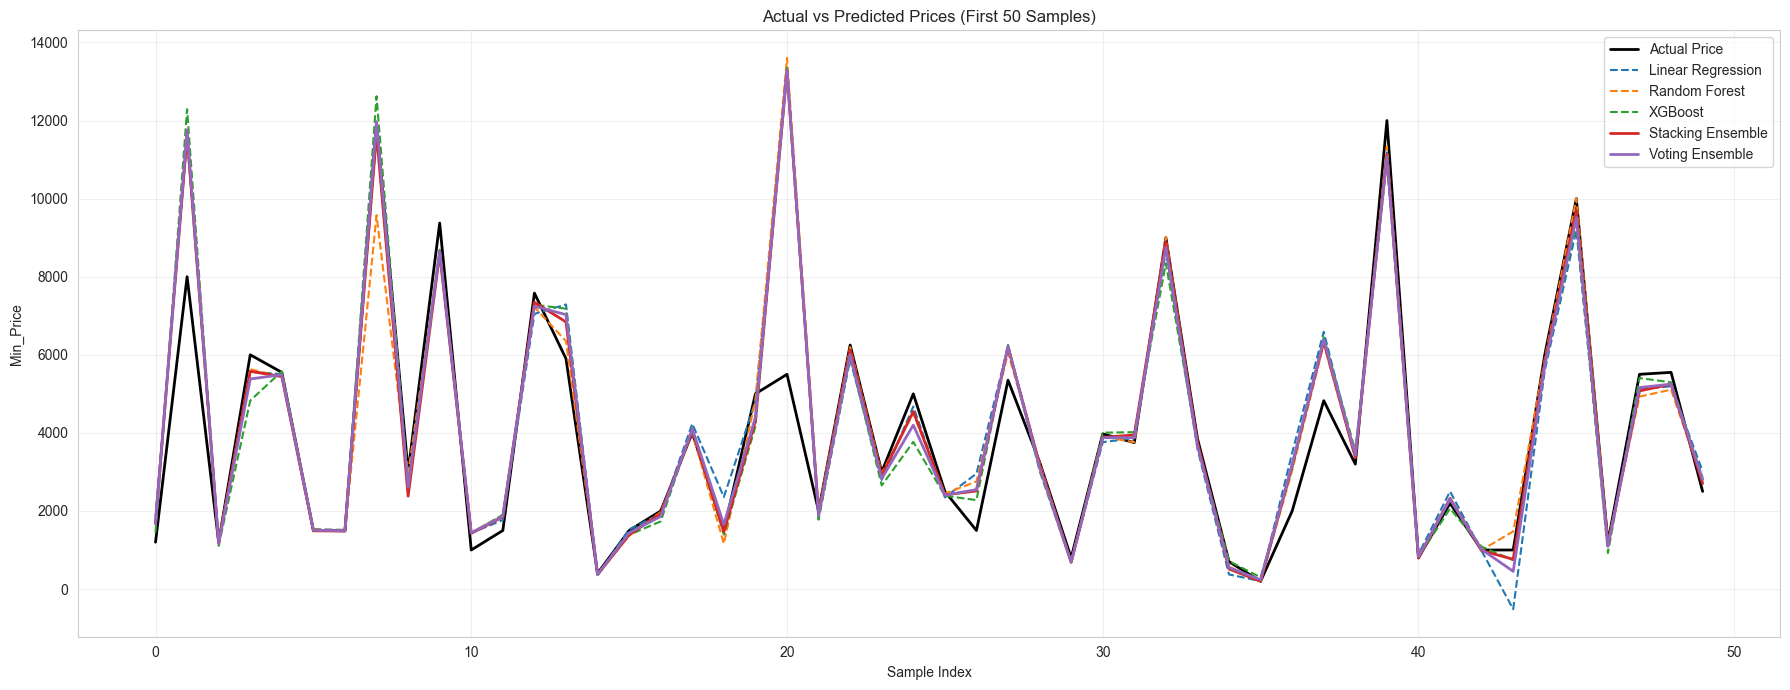


✅ Detailed comparison saved: D:\CUDA_Experiments\Git_HUB\Machine-Learning\AgriCast360\AgriCast360_V2\Model_Results\15_price_comparison_samples.csv


In [26]:
# CELL 19: PRICE PREDICTION COMPARISON
# Compare actual crop prices against predictions from the trained models

print("\n" + "="*80)
print("ACTUAL VS PREDICTED CROP PRICES")
print("="*80)

comparison_df = pd.DataFrame({
    'Actual_Price': y_test.reset_index(drop=True),
    'Linear_Regression': lr_results['predictions'],
    'Random_Forest': rf_results['predictions'],
    'XGBoost': xgb_results['predictions'],
    'Neural_Network': nn_results['predictions'],
    'Stacking_Ensemble': stacking_results['predictions'],
    'Voting_Ensemble': voting_results['predictions']
})

print("\n📋 SAMPLE OF ACTUAL VS PREDICTED PRICES")
print(comparison_df.head(10))

print("\n📈 MODEL PERFORMANCE SUMMARY (MAE on Test Set)")
mae_summary = pd.Series({
    'Linear Regression': test_mae_lr,
    'Random Forest': test_mae_rf,
    'XGBoost': xgb_results['test_mae'],
    'Neural Network': nn_results['test_mae'],
    'Stacking Ensemble': stacking_results['test_mae'],
    'Voting Ensemble': voting_results['test_mae']
}).sort_values()
print(mae_summary)

# Visual comparison for first 50 observations
plot_sample = comparison_df.head(50)
plt.figure(figsize=(18, 7))
plt.plot(plot_sample.index, plot_sample['Actual_Price'], label='Actual Price', linewidth=2, color='black')
plt.plot(plot_sample.index, plot_sample['Linear_Regression'], label='Linear Regression', linestyle='--')
plt.plot(plot_sample.index, plot_sample['Random_Forest'], label='Random Forest', linestyle='--')
plt.plot(plot_sample.index, plot_sample['XGBoost'], label='XGBoost', linestyle='--')
plt.plot(plot_sample.index, plot_sample['Stacking_Ensemble'], label='Stacking Ensemble', linewidth=2)
plt.plot(plot_sample.index, plot_sample['Voting_Ensemble'], label='Voting Ensemble', linewidth=2)
plt.title('Actual vs Predicted Prices (First 50 Samples)')
plt.xlabel('Sample Index')
plt.ylabel(target_mandi)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Save comparison for reference
comparison_path = RESULTS_FOLDER / "15_price_comparison_samples.csv"
comparison_df.to_csv(comparison_path, index=False)
print(f"\n✅ Detailed comparison saved: {comparison_path}")

In [28]:
# CELL 20: PRICE PREDICTION METADATA EXPORT
# Create detailed CSV with commodity, market, predictions, and errors

print("\n" + "="*80)
print("DETAILED CROP PRICE PREDICTION EXPORT")
print("="*80)

# Align metadata rows using original indices retained in y_test
target_indices = y_test.index
metadata = mandi_data_clean.loc[target_indices].reset_index(drop=True)

# Identify commodity (crop) and market columns dynamically
commodity_col = None
market_col = None
for col in metadata.columns:
    col_lower = col.lower()
    if commodity_col is None and any(keyword in col_lower for keyword in ["commodity", "crop", "product", "item"]):
        commodity_col = col
    if market_col is None and any(keyword in col_lower for keyword in ["source_mandi", "market", "mandi", "location"]):
        market_col = col

# Build base dataframe
export_df = pd.DataFrame()
export_df['Commodity'] = metadata[commodity_col] if commodity_col else 'Unknown'
export_df['Market'] = metadata[market_col] if market_col else 'Unknown'
export_df['Actual_Price'] = y_test.reset_index(drop=True)

# Gather predictions from available models
prediction_sources = {
    'Linear_Regression': lr_results['predictions'],
    'Random_Forest': rf_results['predictions'],
    'XGBoost': xgb_results['predictions'],
    'Neural_Network': nn_results['predictions'],
    'Stacking_Ensemble': stacking_results['predictions'],
    'Voting_Ensemble': voting_results['predictions'],
    'Linear_Regression_Tuned': lr_tuned_results['predictions'],
    'Random_Forest_Tuned': rf_tuned_results['predictions'],
    'XGBoost_Tuned': xgb_tuned_results['predictions']
}

# Add prediction columns and error metrics
for model_name, preds in prediction_sources.items():
    model_col = f"{model_name}_Predicted"
    diff_col = f"{model_name}_Diff"
    absdiff_col = f"{model_name}_AbsDiff"
    preds_series = pd.Series(preds).reset_index(drop=True)
    export_df[model_col] = preds_series
    export_df[diff_col] = preds_series - export_df['Actual_Price']
    export_df[absdiff_col] = (export_df[diff_col]).abs()

print("\n📋 SAMPLE OUTPUT")
print(export_df.head(10))

# Persist to CSV
metadata_export_path = RESULTS_FOLDER / "16_price_predictions_with_metadata.csv"
export_df.to_csv(metadata_export_path, index=False)
print(f"\n✅ Detailed export saved: {metadata_export_path}")


DETAILED CROP PRICE PREDICTION EXPORT

📋 SAMPLE OUTPUT
     Commodity              Market  Actual_Price  Linear_Regression_Predicted  \
0         Amla  Ahmedabad (Vasana)          1200                  1856.849787   
1          Til              Amreli          8000                 11541.714860   
2     Beetroot  Ahmedabad (Vasana)          1200                  1197.175935   
3  Mango (Raw)               Surat          6000                  5567.209353   
4  Bengal Gram               Dhari          5550                  5505.167451   
5   Amaranthus  Ahmedabad (Vasana)          1500                  1531.375926   
6     Capsicum               Surat          1500                  1515.485765   
7          Til            Bagasara         11950                 11653.366961   
8    Guar Seed              Rajula          3005                  2579.224377   
9    Urd Beans              Rajula          9375                  8636.138673   

   Linear_Regression_Diff  Linear_Regression_AbsDiff

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import base64
from io import BytesIO
import math

def generate_full_report(csv_path, output_path):
    # 1. Load Data
    print(f"Loading data from: {csv_path}")
    # Use 'try-except' in case of path errors on local machines
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Error: The file at {csv_path} was not found.")
        return

    sns.set(style="whitegrid")

    # 2. Dynamic Model Detection
    # Identifies any column ending in '_Predicted' as a model
    pred_cols = [c for c in df.columns if c.endswith('_Predicted')]
    models = [c.replace('_Predicted', '') for c in pred_cols]
    
    print(f"Found {len(models)} models: {models}")

    # 3. Calculate Metrics (MAE)
    mae_data = []
    for model in models:
        # Use existing Diff column if available, else calculate
        abs_diff_col = f"{model}_AbsDiff"
        if abs_diff_col in df.columns:
            mae = df[abs_diff_col].mean()
        else:
            mae = (df['Actual_Price'] - df[f"{model}_Predicted"]).abs().mean()
        mae_data.append({'Model': model, 'MAE': mae})
    
    mae_df = pd.DataFrame(mae_data).sort_values('MAE')

    # Helper: Save plot to in-memory buffer
    def get_img_base64():
        buf = BytesIO()
        plt.savefig(buf, format='png', bbox_inches='tight')
        plt.close()
        buf.seek(0)
        return base64.b64encode(buf.read()).decode('utf-8')

    # --- Viz 1: MAE Comparison ---
    plt.figure(figsize=(12, 6))
    sns.barplot(x='MAE', y='Model', data=mae_df, palette='viridis')
    plt.title('Model Performance Comparison (MAE)')
    img_mae = get_img_base64()

    # --- Viz 2: Grid Scatter Plot (All Models) ---
    # Create a dynamic grid based on number of models
    cols = 3
    rows = math.ceil(len(models) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()

    for i, model in enumerate(models):
        ax = axes[i]
        # Scatter actual vs predicted
        sns.scatterplot(x=df['Actual_Price'], y=df[f"{model}_Predicted"], alpha=0.3, s=15, ax=ax)
        # Add Red Reference Line
        limit = max(df['Actual_Price'].max(), df[f"{model}_Predicted"].max())
        ax.plot([0, limit], [0, limit], 'r--', lw=2)
        ax.set_title(f"{model} (MAE: {mae_df[mae_df['Model']==model]['MAE'].values[0]:.0f})")
    
    # turn off empty subplots
    for j in range(i+1, len(axes)): axes[j].axis('off')
    plt.tight_layout()
    img_grid = get_img_base64()

    # --- Viz 3: Market Insights ---
    top_items = df.groupby('Commodity')['Actual_Price'].mean().sort_values(ascending=False).head(10)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_items.values, y=top_items.index, palette='magma')
    plt.title('Top 10 Most Expensive Commodities')
    img_top = get_img_base64()

    # 4. Generate HTML
    html = f"""
    <html>
    <head>
        <title>Full Model Analysis</title>
        <style>
            body {{ font-family: sans-serif; margin: 40px auto; max-width: 1200px; background: #f4f4f9; padding: 20px; }}
            .card {{ background: white; padding: 30px; margin-bottom: 30px; border-radius: 8px; box-shadow: 0 2px 5px rgba(0,0,0,0.1); }}
            h1, h2 {{ color: #333; text-align: center; }}
            img {{ max-width: 100%; height: auto; display: block; margin: 20px auto; border: 1px solid #ddd; }}
            table {{ width: 100%; border-collapse: collapse; margin-top: 20px; }}
            th, td {{ border: 1px solid #ddd; padding: 12px; text-align: left; }}
            th {{ background-color: #f2f2f2; }}
        </style>
    </head>
    <body>
        <div class="card">
            <h1>AgriCast360 Model Report</h1>
            <p><strong>Total Models Evaluated:</strong> {len(models)}</p>
            <p><strong>Best Model:</strong> {mae_df.iloc[0]['Model']} (MAE: {mae_df.iloc[0]['MAE']:.2f})</p>
        </div>

        <div class="card">
            <h2>1. Performance Overview</h2>
            <img src="data:image/png;base64,{img_mae}">
            {mae_df.to_html(index=False, classes='table', float_format="%.2f")}
        </div>

        <div class="card">
            <h2>2. Deep Dive: Actual vs. Predicted</h2>
            <p align="center">Red line indicates perfect prediction accuracy.</p>
            <img src="data:image/png;base64,{img_grid}">
        </div>

        <div class="card">
            <h2>3. Market Data Insights</h2>
            <img src="data:image/png;base64,{img_top}">
        </div>
    </body>
    </html>
    """

    with open(output_path, "w", encoding='utf-8') as f:
        f.write(html)
    print(f"Report Generated: {output_path}")

if __name__ == "__main__":
    # Your specific path
    path = r"D:\CUDA_Experiments\Git_HUB\Machine-Learning\AgriCast360\AgriCast360_V2\Model_Results\16_price_predictions_with_metadata.csv"
    output = "AgriCast_Full_Report.html"
    
    generate_full_report(path, output)

Loading data from: D:\CUDA_Experiments\Git_HUB\Machine-Learning\AgriCast360\AgriCast360_V2\Model_Results\16_price_predictions_with_metadata.csv
Found 9 models: ['Linear_Regression', 'Random_Forest', 'XGBoost', 'Neural_Network', 'Stacking_Ensemble', 'Voting_Ensemble', 'Linear_Regression_Tuned', 'Random_Forest_Tuned', 'XGBoost_Tuned']
Report Generated: AgriCast_Full_Report.html
Report Generated: AgriCast_Full_Report.html


In [5]:
import pandas as pd
import numpy as np
import os
import json
from datetime import datetime

# --- CONFIG ---
csv_path = r"D:\CUDA_Experiments\Git_HUB\Machine-Learning\AgriCast360\AgriCast360_V2\Model_Results\16_price_predictions_with_metadata.csv"
output_dir = os.path.dirname(csv_path)
html_path = os.path.join(output_dir, "AgriCast360_Interactive_Report.html")

# Read the CSV file
print("📖 Reading CSV file...")
df = pd.read_csv(csv_path)
print(f"✅ Loaded {len(df):,} records with {len(df.columns)} columns\n")

# --- EXTRACT MODEL INFORMATION ---
# Identify all model names by looking for _Predicted columns
model_names = []
for col in df.columns:
    if col.endswith("_Predicted"):
        model_name = col.replace("_Predicted", "")
        model_names.append(model_name)

print(f"📊 Models found: {len(model_names)}")
for i, m in enumerate(model_names, 1):
    print(f"   {i}. {m}")

# --- COMPUTE MODEL METRICS ---
model_metrics = {}
for model in model_names:
    abs_diff_col = f"{model}_AbsDiff"
    pred_col = f"{model}_Predicted"
    if abs_diff_col in df.columns:
        mae = df[abs_diff_col].mean()
        rmse = np.sqrt((df[abs_diff_col] ** 2).mean())
        mape = (df[abs_diff_col] / df['Actual_Price'] * 100).mean()
        mean_pred = df[pred_col].mean()
        model_metrics[model] = {
            "MAE": mae,
            "RMSE": rmse,
            "MAPE": mape,
            "Mean_Prediction": mean_pred
        }

sorted_models = sorted(model_metrics.items(), key=lambda x: x[1]["MAE"])

# --- GET UNIQUE VALUES ---
commodities = sorted(df['Commodity'].unique().tolist())
markets = sorted(df['Market'].unique().tolist())

print(f"\n🥕 Commodities: {len(commodities)}")
print(f"🏪 Markets: {len(markets)}")

# --- FIND MIN/MAX PRICE COMMODITIES ---
min_price = df['Actual_Price'].min()
max_price = df['Actual_Price'].max()
min_price_row = df[df['Actual_Price'] == min_price].iloc[0]
max_price_row = df[df['Actual_Price'] == max_price].iloc[0]
min_commodity = min_price_row['Commodity']
min_market = min_price_row['Market']
max_commodity = max_price_row['Commodity']
max_market = max_price_row['Market']

print(f"\n💰 Price Range Info:")
print(f"   Min: ₹{min_price:,.0f} - {min_commodity} at {min_market}")
print(f"   Max: ₹{max_price:,.0f} - {max_commodity} at {max_market}")

# --- ANALYZE MODEL PERFORMANCE BY PRICE RANGE ---
price_ranges = [
    {"min": 0, "max": 500, "label": "₹0-500"},
    {"min": 500, "max": 1000, "label": "₹500-1K"},
    {"min": 1000, "max": 2500, "label": "₹1K-2.5K"},
    {"min": 2500, "max": 5000, "label": "₹2.5K-5K"},
    {"min": 5000, "max": 10000, "label": "₹5K-10K"},
    {"min": 10000, "max": float('inf'), "label": "₹10K+"}
]

best_models_by_range = {}
for price_range in price_ranges:
    range_df = df[(df['Actual_Price'] >= price_range['min']) & (df['Actual_Price'] < price_range['max'])]
    if len(range_df) > 0:
        range_maes = {}
        for model in model_names:
            abs_diff_col = f"{model}_AbsDiff"
            range_maes[model] = range_df[abs_diff_col].mean()
        best_model = min(range_maes, key=range_maes.get)
        best_mae = range_maes[best_model]
        best_models_by_range[price_range['label']] = {
            "model": best_model,
            "mae": best_mae,
            "count": len(range_df)
        }
        print(f"\n📊 {price_range['label']} ({len(range_df)} records):")
        print(f"   Best: {best_model} (MAE: ₹{best_mae:,.1f})")

print(f"\n⏳ Generating HTML report...")

# --- ANALYZE BEST MODELS BY COMMODITY (LOWEST ERROR) ---
best_models_by_error = {}
error_ranges = [
    {"min": 0, "max": 100, "label": "Low", "emoji": "🟢"},
    {"min": 100, "max": 500, "label": "Medium", "emoji": "🟡"},
    {"min": 500, "max": 999, "label": "High", "emoji": "🟠"},
    {"min": 999, "max": float('inf'), "label": "Very High", "emoji": "🔴"}
]

for commodity in commodities:
    comm_df = df[df['Commodity'] == commodity]
    if len(comm_df) > 0:
        comm_maes = {}
        for model in model_names:
            abs_diff_col = f"{model}_AbsDiff"
            comm_maes[model] = comm_df[abs_diff_col].mean()
        best_model = min(comm_maes, key=comm_maes.get)
        best_error = comm_maes[best_model]
        
        # Determine error range category
        error_label = "Very High"
        emoji = "🔴"
        for error_range in error_ranges:
            if error_range['min'] <= best_error < error_range['max']:
                error_label = error_range['label']
                emoji = error_range['emoji']
                break
        
        best_models_by_error[commodity] = {
            "model": best_model,
            "error": best_error,
            "error_label": error_label,
            "emoji": emoji,
            "count": len(comm_df)
        }

best_models_by_error_json = json.dumps(best_models_by_error)

# --- PREPARE DATA FOR JAVASCRIPT ---
model_names_json = json.dumps(model_names)
model_metrics_json = json.dumps({k: v for k, v in sorted_models})
best_models_by_range_json = json.dumps(best_models_by_range)
commodities_json = json.dumps(commodities)
markets_json = json.dumps(markets)

# Prepare data for table
table_data = []
for idx, row in df.iterrows():
    record = {
        "Commodity": row['Commodity'],
        "Market": row['Market'],
        "Actual_Price": float(row['Actual_Price'])
    }
    
    # Add predictions for each model
    for model in model_names:
        pred_col = f"{model}_Predicted"
        diff_col = f"{model}_Diff"
        abs_diff_col = f"{model}_AbsDiff"
        
        record[f"{model}_Pred"] = float(row[pred_col])
        record[f"{model}_Diff"] = float(row[diff_col])
        record[f"{model}_AbsDiff"] = float(row[abs_diff_col])
    
    table_data.append(record)

table_data_json = json.dumps(table_data)

# --- BUILD HTML PAGE ---
html_content = f"""<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>AgriCast360 - Price Predictions Report</title>
    <script src="https://cdn.jsdelivr.net/npm/chart.js@3.9.1/dist/chart.min.js"></script>
    <script src="https://cdn.jsdelivr.net/npm/fuse.js@6.6.2/dist/fuse.min.js"></script>
    <style>
        * {{
            margin: 0;
            padding: 0;
            box-sizing: border-box;
        }}

        body {{
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: #333;
            padding: 20px;
        }}

        .container {{
            max-width: 1800px;
            margin: 0 auto;
            background: white;
            border-radius: 15px;
            box-shadow: 0 20px 60px rgba(0, 0, 0, 0.3);
            overflow: hidden;
        }}

        .header {{
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            padding: 40px;
            text-align: center;
        }}

        .header h1 {{
            font-size: 2.5em;
            margin-bottom: 10px;
            font-weight: 700;
        }}

        .header p {{
            font-size: 1.1em;
            opacity: 0.9;
        }}

        .content {{
            padding: 30px;
        }}

        .section {{
            margin-bottom: 40px;
        }}

        .section-title {{
            font-size: 1.8em;
            color: #667eea;
            margin-bottom: 20px;
            border-bottom: 3px solid #667eea;
            padding-bottom: 10px;
            font-weight: 700;
        }}

        .stats-grid {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(200px, 1fr));
            gap: 20px;
            margin-bottom: 30px;
        }}

        .stat-card {{
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            padding: 20px;
            border-radius: 10px;
            text-align: center;
            box-shadow: 0 5px 15px rgba(102, 126, 234, 0.3);
        }}

        .stat-card .value {{
            font-size: 2em;
            font-weight: bold;
            margin: 10px 0;
        }}

        .stat-card .label {{
            font-size: 0.9em;
            opacity: 0.9;
        }}

        .model-cards {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(280px, 1fr));
            gap: 20px;
            margin-bottom: 30px;
        }}

        .model-card {{
            border: 2px solid #667eea;
            border-radius: 10px;
            padding: 20px;
            background: #f8f9ff;
            transition: all 0.3s ease;
        }}

        .model-card:hover {{
            transform: translateY(-5px);
            box-shadow: 0 10px 25px rgba(102, 126, 234, 0.2);
            border-color: #764ba2;
        }}

        .price-range-cards {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(250px, 1fr));
            gap: 15px;
            margin-bottom: 30px;
        }}

        .price-range-card {{
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            border-radius: 10px;
            padding: 20px;
            color: white;
            box-shadow: 0 8px 20px rgba(102, 126, 234, 0.4);
            transition: all 0.3s ease;
            border: 2px solid rgba(255, 255, 255, 0.2);
        }}

        .price-range-card:hover {{
            transform: translateY(-5px);
            box-shadow: 0 15px 35px rgba(102, 126, 234, 0.5);
            border-color: rgba(255, 255, 255, 0.4);
        }}

        .price-range-label {{
            font-weight: 700;
            font-size: 1.15em;
            margin-bottom: 12px;
            color: #fff;
            text-shadow: 1px 1px 2px rgba(0, 0, 0, 0.2);
            letter-spacing: 0.5px;
        }}

        .best-model-name {{
            font-size: 1.4em;
            font-weight: 800;
            margin: 12px 0;
            color: #ffeb99;
            text-shadow: 1px 1px 3px rgba(0, 0, 0, 0.3);
            word-wrap: break-word;
        }}

        .price-range-metric {{
            margin: 10px 0;
            display: flex;
            justify-content: space-between;
            align-items: center;
            font-size: 0.97em;
            padding: 8px 0;
            border-bottom: 1px solid rgba(255, 255, 255, 0.15);
        }}

        .price-range-metric:last-child {{
            border-bottom: none;
        }}

        .price-range-metric .metric-label {{
            color: rgba(255, 255, 255, 0.9);
            font-weight: 600;
        }}

        .price-range-metric .metric-value {{
            font-weight: 700;
            font-size: 1.1em;
            color: #ffeb99;
            text-shadow: 1px 1px 2px rgba(0, 0, 0, 0.2);
        }}

        .commodity-cards {{
            display: grid;
            grid-template-columns: repeat(auto-fill, minmax(300px, 1fr));
            gap: 15px;
            margin-bottom: 30px;
        }}

        .commodity-card {{
            background: white;
            border-left: 4px solid #667eea;
            border-radius: 8px;
            padding: 18px;
            box-shadow: 0 4px 12px rgba(0, 0, 0, 0.08);
            transition: all 0.3s ease;
        }}

        .commodity-card:hover {{
            transform: translateY(-3px);
            box-shadow: 0 8px 20px rgba(102, 126, 234, 0.15);
            border-left-color: #764ba2;
        }}

        .commodity-header {{
            display: flex;
            justify-content: space-between;
            align-items: center;
            margin-bottom: 12px;
        }}

        .commodity-name {{
            font-size: 1.2em;
            font-weight: 700;
            color: #333;
        }}

        .error-badge {{
            padding: 4px 12px;
            border-radius: 12px;
            font-size: 0.85em;
            font-weight: 600;
        }}

        .error-badge.low {{
            background: #d4edda;
            color: #155724;
        }}

        .error-badge.medium {{
            background: #fff3cd;
            color: #856404;
        }}

        .error-badge.high {{
            background: #ffe5cc;
            color: #cc6600;
        }}

        .error-badge.veryhigh {{
            background: #f8d7da;
            color: #721c24;
        }}

        .commodity-model {{
            display: flex;
            justify-content: space-between;
            align-items: center;
            padding: 10px 0;
            border-bottom: 1px solid #eee;
            margin-bottom: 10px;
        }}

        .commodity-model .label {{
            font-weight: 600;
            color: #666;
            font-size: 0.9em;
        }}

        .commodity-model .model-name {{
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            padding: 5px 12px;
            border-radius: 6px;
            font-weight: 700;
            font-size: 0.95em;
            margin: 0;
        }}

        .commodity-stat {{
            display: flex;
            justify-content: space-between;
            align-items: center;
            padding: 8px 0;
            font-size: 0.95em;
        }}

        .commodity-stat .label {{
            color: #777;
            font-weight: 600;
        }}

        .commodity-stat .value {{
            color: #667eea;
            font-weight: 700;
        }}

        .filter-btn {{
            padding: 8px 16px;
            background: white;
            border: 2px solid #667eea;
            color: #667eea;
            border-radius: 6px;
            cursor: pointer;
            font-weight: 600;
            transition: all 0.3s ease;
        }}

        .filter-btn:hover {{
            background: #f0f4ff;
        }}

        .filter-btn.active {{
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            border-color: transparent;
        }}

        .model-rank {{
            display: inline-block;
            background: #667eea;
            color: white;
            padding: 5px 15px;
            border-radius: 20px;
            font-weight: bold;
            font-size: 0.9em;
            margin-bottom: 10px;
        }}

        .model-name {{
            font-size: 1.3em;
            font-weight: bold;
            color: #333;
            margin: 10px 0;
        }}

        .metric {{
            margin: 10px 0;
            display: flex;
            justify-content: space-between;
            align-items: center;
        }}

        .metric-label {{
            color: #666;
            font-size: 0.95em;
        }}

        .metric-value {{
            font-weight: bold;
            color: #667eea;
            font-size: 1.1em;
        }}

        .filters-container {{
            background: #f8f9ff;
            padding: 20px;
            border-radius: 10px;
            margin-bottom: 30px;
        }}

        .filters-grid {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(250px, 1fr));
            gap: 15px;
        }}

        .filter-group {{
            display: flex;
            flex-direction: column;
        }}

        .filter-group label {{
            font-weight: 600;
            margin-bottom: 8px;
            color: #333;
        }}

        .filter-group input,
        .filter-group select {{
            padding: 12px;
            border: 2px solid #ddd;
            border-radius: 6px;
            font-size: 1em;
            transition: all 0.3s ease;
        }}

        .filter-group input:focus,
        .filter-group select:focus {{
            outline: none;
            border-color: #667eea;
            box-shadow: 0 0 0 3px rgba(102, 126, 234, 0.1);
        }}

        .btn {{
            padding: 12px 25px;
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            border: none;
            border-radius: 6px;
            cursor: pointer;
            font-weight: 600;
            transition: all 0.3s ease;
            align-self: flex-end;
        }}

        .btn:hover {{
            transform: translateY(-2px);
            box-shadow: 0 10px 20px rgba(102, 126, 234, 0.3);
        }}

        .charts-grid {{
            display: grid;
            grid-template-columns: repeat(2, 1fr);
            gap: 20px;
            margin-bottom: 30px;
        }}

        .chart-container {{
            background: white;
            border: 2px solid #e0e0e0;
            border-radius: 10px;
            padding: 20px;
            position: relative;
            height: 400px;
        }}

        .table-container {{
            overflow-x: auto;
            border-radius: 10px;
            box-shadow: 0 2px 10px rgba(0, 0, 0, 0.1);
        }}

        table {{
            width: 100%;
            border-collapse: collapse;
            background: white;
        }}

        thead {{
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
        }}

        th {{
            padding: 15px;
            text-align: left;
            font-weight: 600;
            position: sticky;
            top: 0;
            z-index: 10;
        }}

        td {{
            padding: 12px 15px;
            border-bottom: 1px solid #eee;
        }}

        tbody tr:hover {{
            background: #f8f9ff;
        }}

        tbody tr:nth-child(even) {{
            background: #fafbff;
        }}

        .price-value {{
            font-weight: 600;
            color: #667eea;
        }}

        .error-low {{
            color: #28a745;
            font-weight: 600;
        }}

        .error-medium {{
            color: #ffc107;
            font-weight: 600;
        }}

        .error-high {{
            color: #dc3545;
            font-weight: 600;
        }}

        .pagination {{
            display: flex;
            justify-content: center;
            gap: 5px;
            margin-top: 20px;
        }}

        .pagination button {{
            padding: 8px 12px;
            background: #667eea;
            color: white;
            border: none;
            border-radius: 5px;
            cursor: pointer;
            font-weight: 600;
        }}

        .pagination button.active {{
            background: #764ba2;
        }}

        .pagination button:disabled {{
            background: #ccc;
            cursor: not-allowed;
        }}

        .record-count {{
            text-align: center;
            color: #666;
            margin-top: 10px;
            font-size: 0.95em;
        }}

        @media (max-width: 768px) {{
            .charts-grid {{
                grid-template-columns: 1fr;
            }}

            .model-cards {{
                grid-template-columns: 1fr;
            }}

            .header h1 {{
                font-size: 1.8em;
            }}

            table {{
                font-size: 0.9em;
            }}

            th, td {{
                padding: 8px 10px;
            }}
        }}
    </style>
</head>
<body>
    <div class="container">
        <div class="header">
            <h1>🌾 AgriCast360 - Price Predictions Report</h1>
            <p>Comprehensive Market Price Analysis & Model Performance Comparison</p>
        </div>

        <div class="content">
            <!-- Summary Statistics -->
            <div class="section">
                <div class="section-title">📊 Summary Statistics</div>
                <div class="stats-grid">
                    <div class="stat-card">
                        <div class="label">Total Records</div>
                        <div class="value">{len(df):,}</div>
                    </div>
                    <div class="stat-card">
                        <div class="label">Commodities</div>
                        <div class="value">{len(commodities)}</div>
                    </div>
                    <div class="stat-card">
                        <div class="label">Markets</div>
                        <div class="value">{len(markets)}</div>
                    </div>
                    <div class="stat-card">
                        <div class="label">Models Evaluated</div>
                        <div class="value">{len(model_names)}</div>
                    </div>
                    <div class="stat-card">
                        <div class="label">Avg Price</div>
                        <div class="value">₹{df['Actual_Price'].mean():,.0f}</div>
                    </div>
                    <div class="stat-card">
                        <div class="label">Price Range</div>
                        <div class="value">₹{df['Actual_Price'].min():,.0f} - ₹{df['Actual_Price'].max():,.0f}</div>
                        <div style="font-size: 0.85em; margin-top: 10px; line-height: 1.4; color: #eee;">
                            <div>📍 Min: {min_commodity} ({min_market})</div>
                            <div>📍 Max: {max_commodity} ({max_market})</div>
                        </div>
                    </div>
                </div>
            </div>

            <!-- Model Performance Rankings -->
            <div class="section">
                <div class="section-title">🏆 Model Performance Rankings (by MAE)</div>
                <div class="model-cards">
"""

# Add model ranking cards
for rank, (model, metrics) in enumerate(sorted_models, 1):
    medal = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉" if rank == 3 else "📍"
    html_content += f"""
                    <div class="model-card">
                        <div class="model-rank">{medal} Rank #{rank}</div>
                        <div class="model-name">{model}</div>
                        <div class="metric">
                            <span class="metric-label">Mean Predicted Price</span>
                            <span class="metric-value">₹{metrics['Mean_Prediction']:,.1f}</span>
                        </div>
                        <div class="metric">
                            <span class="metric-label">Mean Absolute Error (MAE)</span>
                            <span class="metric-value">₹{metrics['MAE']:,.1f}</span>
                        </div>
                        <div class="metric">
                            <span class="metric-label">Root Mean Squared Error (RMSE)</span>
                            <span class="metric-value">₹{metrics['RMSE']:,.1f}</span>
                        </div>
                        <div class="metric">
                            <span class="metric-label">Mean Absolute Percentage Error (MAPE)</span>
                            <span class="metric-value">{metrics['MAPE']:.2f}%</span>
                        </div>
                    </div>
"""

html_content += """
                </div>
            </div>

            <!-- Best Models by Price Range -->
            <div class="section">
                <div class="section-title">💹 Best Models by Price Range</div>
                <div class="price-range-cards">
"""

for price_range_label, model_info in best_models_by_range.items():
    html_content += f"""
                    <div class="price-range-card">
                        <div class="price-range-label">{price_range_label}</div>
                        <div class="best-model-name">{model_info['model']}</div>
                        <div class="price-range-metric">
                            <span class="metric-label">Best MAE</span>
                            <span class="metric-value">₹{model_info['mae']:,.1f}</span>
                        </div>
                        <div class="price-range-metric">
                            <span class="metric-label">Records</span>
                            <span class="metric-value">{model_info['count']:,}</span>
                        </div>
                    </div>
"""

html_content += """
                </div>
            </div>

            <!-- Best Models by Commodity (Grouped by Error Level) -->
            <div class="section">
                <div class="section-title">🥬 Best Models by Commodity (Grouped by Error Level)</div>
                <div id="commodity-filters-container" style="margin-bottom: 20px;">
                    <div style="display: flex; gap: 10px; flex-wrap: wrap;">
                        <button class="filter-btn active" onclick="filterCommoditiesByError('all')">All Commodities</button>
                        <button class="filter-btn" onclick="filterCommoditiesByError('low')">🟢 Low Error (&lt;100)</button>
                        <button class="filter-btn" onclick="filterCommoditiesByError('medium')">🟡 Medium Error (100-500)</button>
                        <button class="filter-btn" onclick="filterCommoditiesByError('high')">🟠 High Error (500-999)</button>
                        <button class="filter-btn" onclick="filterCommoditiesByError('veryhigh')">🔴 Very High Error (999+)</button>
                    </div>
                </div>
                <div class="commodity-cards" id="commodity-cards-container">
"""

# Sort commodities by their best error for better display
sorted_commodities = sorted(best_models_by_error.items(), key=lambda x: x[1]['error'])

for commodity, model_info in sorted_commodities:
    html_content += f"""
                    <div class="commodity-card" data-error-level="{model_info['error_label'].lower()}">
                        <div class="commodity-header">
                            <div class="commodity-name">{commodity}</div>
                            <div class="error-badge {model_info['error_label'].lower()}">{model_info['emoji']} {model_info['error_label']}</div>
                        </div>
                        <div class="commodity-model">
                            <span class="label">Best Model:</span>
                            <span class="model-name">{model_info['model']}</span>
                        </div>
                        <div class="commodity-stat">
                            <span class="label">Best Error (MAE):</span>
                            <span class="value">₹{model_info['error']:,.1f}</span>
                        </div>
                        <div class="commodity-stat">
                            <span class="label">Records:</span>
                            <span class="value">{model_info['count']}</span>
                        </div>
                    </div>
"""

html_content += """
                </div>
            </div>

            <!-- Filters Section -->
            <div class="section">
                <div class="section-title">🔍 Search & Filter</div>
                <div class="filters-container">
                    <div class="filters-grid">
                        <div class="filter-group">
                            <label for="commodity-filter">📦 Commodity</label>
                            <select id="commodity-filter">
                                <option value="">All Commodities</option>
"""

for comm in commodities:
    html_content += f'                                <option value="{comm}">{comm}</option>\n'

html_content += """
                            </select>
                        </div>
                        <div class="filter-group">
                            <label for="market-filter">🏪 Market</label>
                            <select id="market-filter">
                                <option value="">All Markets</option>
"""

for market in markets:
    html_content += f'                                <option value="{market}">{market}</option>\n'

html_content += f"""
                            </select>
                        </div>
                        <div class="filter-group">
                            <label for="search-input">🔎 Search</label>
                            <input type="text" id="search-input" placeholder="Search commodity or market...">
                        </div>
                        <div class="filter-group">
                            <label>&nbsp;</label>
                            <button class="btn" onclick="resetFilters()">Reset Filters</button>
                        </div>
                    </div>
                </div>
            </div>

            <!-- Charts Section -->
            <div class="section">
                <div class="section-title">📈 Performance Visualizations</div>
                <div class="charts-grid">
                    <div class="chart-container">
                        <canvas id="mae-chart"></canvas>
                    </div>
                    <div class="chart-container">
                        <canvas id="rmse-chart"></canvas>
                    </div>
                    <div class="chart-container">
                        <canvas id="mape-chart"></canvas>
                    </div>
                    <div class="chart-container">
                        <canvas id="price-distribution-chart"></canvas>
                    </div>
                    <div class="chart-container">
                        <canvas id="error-distribution-chart"></canvas>
                    </div>
                    <div class="chart-container">
                        <canvas id="commodity-avg-error-chart"></canvas>
                    </div>
                    <div class="chart-container">
                        <canvas id="commodity-price-by-market-chart"></canvas>
                    </div>
                </div>
            </div>

            <!-- Data Table Section -->
            <div class="section">
                <div class="section-title">📋 Detailed Results Table</div>
                <div class="table-container">
                    <table>
                        <thead>
                            <tr>
                                <th>Commodity</th>
                                <th>Market</th>
                                <th>Actual Price</th>
                                <th>Best Model Prediction</th>
                                <th>Best Model</th>
                                <th>Best Error</th>
                                <th>Worst Error</th>
                                <th>Avg Error (All Models)</th>
                            </tr>
                        </thead>
                        <tbody id="table-body">
                        </tbody>
                    </table>
                </div>
                <div class="record-count">
                    Showing <span id="showing-records">0</span> of <span id="total-records">{len(df):,}</span> records
                </div>
                <div class="pagination">
                    <button onclick="previousPage()">← Previous</button>
                    <span id="page-info"></span>
                    <button onclick="nextPage()">Next →</button>
                </div>
            </div>
        </div>
    </div>

    <script>
        // Data
        const allData = {table_data_json};
        const modelNames = {model_names_json};
        const modelMetrics = {model_metrics_json};
        const commodities = {commodities_json};
        const markets = {markets_json};

        let filteredData = [...allData];
        let currentPage = 1;
        const recordsPerPage = 20;
        let chartInstances = {{}};

        // Filter Functions
        function applyFilters() {{
            const commodityFilter = document.getElementById('commodity-filter').value;
            const marketFilter = document.getElementById('market-filter').value;
            const searchFilter = document.getElementById('search-input').value.toLowerCase();

            filteredData = allData.filter(row => {{
                const commodityMatch = !commodityFilter || row.Commodity === commodityFilter;
                const marketMatch = !marketFilter || row.Market === marketFilter;
                const searchMatch = !searchFilter || 
                    row.Commodity.toLowerCase().includes(searchFilter) ||
                    row.Market.toLowerCase().includes(searchFilter);
                return commodityMatch && marketMatch && searchMatch;
            }});

            currentPage = 1;
            updateTable();
            updateCharts();
        }}

        function resetFilters() {{
            document.getElementById('commodity-filter').value = '';
            document.getElementById('market-filter').value = '';
            document.getElementById('search-input').value = '';
            filteredData = [...allData];
            currentPage = 1;
            updateTable();
            updateCharts();
        }}

        function filterCommoditiesByError(level) {{
            const cards = document.querySelectorAll('.commodity-card');
            const buttons = document.querySelectorAll('.filter-btn');
            
            // Update button states
            buttons.forEach(btn => btn.classList.remove('active'));
            event.target.classList.add('active');
            
            // Filter cards
            if (level === 'all') {{
                cards.forEach(card => card.style.display = 'block');
            }} else {{
                const errorLevelMap = {{
                    'low': 'low',
                    'medium': 'medium',
                    'high': 'high',
                    'veryhigh': 'veryhigh'
                }};
                
                cards.forEach(card => {{
                    const cardLevel = card.getAttribute('data-error-level');
                    if (cardLevel === errorLevelMap[level]) {{
                        card.style.display = 'block';
                    }} else {{
                        card.style.display = 'none';
                    }}
                }});
            }}
        }}

        // Pagination
        function previousPage() {{
            if (currentPage > 1) {{
                currentPage--;
                updateTable();
            }}
        }}

        function nextPage() {{
            const maxPage = Math.ceil(filteredData.length / recordsPerPage);
            if (currentPage < maxPage) {{
                currentPage++;
                updateTable();
            }}
        }}

        // Update Table
        function updateTable() {{
            const tbody = document.getElementById('table-body');
            tbody.innerHTML = '';

            const start = (currentPage - 1) * recordsPerPage;
            const end = start + recordsPerPage;
            const pageData = filteredData.slice(start, end);

            pageData.forEach(row => {{
                let bestError = Infinity;
                let worstError = 0;
                let bestModel = '';
                let bestPrediction = 0;
                let sumError = 0;

                modelNames.forEach(model => {{
                    const absDiffKey = model + '_AbsDiff';
                    const error = row[absDiffKey];
                    sumError += error;
                    
                    if (error < bestError) {{
                        bestError = error;
                        bestModel = model;
                        bestPrediction = row[model + '_Pred'];
                    }}
                    worstError = Math.max(worstError, error);
                }});

                const avgError = sumError / modelNames.length;
                const errorClass = bestError < 100 ? 'error-low' : bestError < 300 ? 'error-medium' : 'error-high';

                const tr = document.createElement('tr');
                tr.innerHTML = `
                    <td><strong>${{row.Commodity}}</strong></td>
                    <td>${{row.Market}}</td>
                    <td class="price-value">₹${{row.Actual_Price.toLocaleString('en-IN', {{maximumFractionDigits: 0}})}}</td>
                    <td class="price-value">₹${{bestPrediction.toLocaleString('en-IN', {{maximumFractionDigits: 0}})}}</td>
                    <td><strong>${{bestModel.replace(/_/g, ' ')}}</strong></td>
                    <td><span class="${{errorClass}}">₹${{bestError.toFixed(2)}}</span></td>
                    <td>₹${{worstError.toFixed(2)}}</td>
                    <td>₹${{avgError.toFixed(2)}}</td>
                `;
                tbody.appendChild(tr);
            }});

            // Update pagination info
            const maxPage = Math.ceil(filteredData.length / recordsPerPage);
            document.getElementById('page-info').textContent = `Page ${{currentPage}} of ${{maxPage}}`;
            document.getElementById('showing-records').textContent = Math.min(end, filteredData.length);
            document.getElementById('total-records').textContent = filteredData.length.toLocaleString('en-IN');
        }}

        // Chart Functions
        function updateCharts() {{
            updateMAEChart();
            updateRMSEChart();
            updateMAPEChart();
            updatePriceDistribution();
            updateErrorDistribution();
            updateCommodityAvgError();
            updateCommodityPriceByMarket();
        }}

        function updateMAEChart() {{
            const ctx = document.getElementById('mae-chart').getContext('2d');
            const models = Object.keys(modelMetrics).sort((a, b) => modelMetrics[a].MAE - modelMetrics[b].MAE);
            const maes = models.map(m => modelMetrics[m].MAE);
            
            if (chartInstances.mae) chartInstances.mae.destroy();
            
            chartInstances.mae = new Chart(ctx, {{
                type: 'bar',
                data: {{
                    labels: models.map(m => m.replace(/_/g, ' ')),
                    datasets: [{{
                        label: 'Mean Absolute Error (MAE)',
                        data: maes,
                        backgroundColor: 'rgba(102, 126, 234, 0.7)',
                        borderColor: 'rgba(102, 126, 234, 1)',
                        borderWidth: 2,
                        borderRadius: 5
                    }}]
                }},
                options: {{
                    responsive: true,
                    maintainAspectRatio: false,
                    plugins: {{
                        legend: {{ display: true, position: 'top' }}
                    }},
                    scales: {{
                        y: {{ beginAtZero: true, title: {{ display: true, text: 'MAE (₹)' }} }}
                    }}
                }}
            }});
        }}

        function updateRMSEChart() {{
            const ctx = document.getElementById('rmse-chart').getContext('2d');
            const models = Object.keys(modelMetrics).sort((a, b) => modelMetrics[a].RMSE - modelMetrics[b].RMSE);
            const rmses = models.map(m => modelMetrics[m].RMSE);
            
            if (chartInstances.rmse) chartInstances.rmse.destroy();
            
            chartInstances.rmse = new Chart(ctx, {{
                type: 'line',
                data: {{
                    labels: models.map(m => m.replace(/_/g, ' ')),
                    datasets: [{{
                        label: 'Root Mean Squared Error (RMSE)',
                        data: rmses,
                        borderColor: 'rgba(220, 53, 69, 1)',
                        backgroundColor: 'rgba(220, 53, 69, 0.1)',
                        borderWidth: 3,
                        fill: true,
                        tension: 0.4,
                        pointRadius: 6,
                        pointBackgroundColor: 'rgba(220, 53, 69, 1)',
                        pointBorderColor: 'white',
                        pointBorderWidth: 2
                    }}]
                }},
                options: {{
                    responsive: true,
                    maintainAspectRatio: false,
                    plugins: {{
                        legend: {{ display: true, position: 'top' }}
                    }},
                    scales: {{
                        y: {{ beginAtZero: true, title: {{ display: true, text: 'RMSE (₹)' }} }}
                    }}
                }}
            }});
        }}

        function updateMAPEChart() {{
            const ctx = document.getElementById('mape-chart').getContext('2d');
            const models = Object.keys(modelMetrics).sort((a, b) => modelMetrics[a].MAPE - modelMetrics[b].MAPE);
            const mapes = models.map(m => modelMetrics[m].MAPE);
            
            if (chartInstances.mape) chartInstances.mape.destroy();
            
            chartInstances.mape = new Chart(ctx, {{
                type: 'bar',
                data: {{
                    labels: models.map(m => m.replace(/_/g, ' ')),
                    datasets: [{{
                        label: 'Mean Absolute Percentage Error (MAPE)',
                        data: mapes,
                        backgroundColor: 'rgba(40, 167, 69, 0.7)',
                        borderColor: 'rgba(40, 167, 69, 1)',
                        borderWidth: 2,
                        borderRadius: 5
                    }}]
                }},
                options: {{
                    responsive: true,
                    maintainAspectRatio: false,
                    plugins: {{
                        legend: {{ display: true, position: 'top' }}
                    }},
                    scales: {{
                        y: {{ beginAtZero: true, title: {{ display: true, text: 'MAPE (%)' }} }}
                    }}
                }}
            }});
        }}

        function updatePriceDistribution() {{
            const ctx = document.getElementById('price-distribution-chart').getContext('2d');
            
            const priceRanges = [
                {{ min: 0, max: 500, label: '₹0-500' }},
                {{ min: 500, max: 1000, label: '₹500-1K' }},
                {{ min: 1000, max: 2500, label: '₹1K-2.5K' }},
                {{ min: 2500, max: 5000, label: '₹2.5K-5K' }},
                {{ min: 5000, max: 10000, label: '₹5K-10K' }},
                {{ min: 10000, max: Infinity, label: '₹10K+' }}
            ];
            
            const counts = priceRanges.map(range => {{
                return filteredData.filter(row => 
                    row.Actual_Price >= range.min && row.Actual_Price < range.max
                ).length;
            }});
            
            if (chartInstances.priceDistribution) chartInstances.priceDistribution.destroy();
            
            chartInstances.priceDistribution = new Chart(ctx, {{
                type: 'doughnut',
                data: {{
                    labels: priceRanges.map(r => r.label),
                    datasets: [{{
                        data: counts,
                        backgroundColor: [
                            'rgba(102, 126, 234, 0.8)',
                            'rgba(118, 75, 162, 0.8)',
                            'rgba(40, 167, 69, 0.8)',
                            'rgba(255, 193, 7, 0.8)',
                            'rgba(255, 152, 0, 0.8)',
                            'rgba(244, 67, 54, 0.8)'
                        ],
                        borderColor: 'white',
                        borderWidth: 2
                    }}]
                }},
                options: {{
                    responsive: true,
                    maintainAspectRatio: false,
                    plugins: {{
                        legend: {{ position: 'bottom' }}
                    }}
                }}
            }});
        }}

        function updateErrorDistribution() {{
            const ctx = document.getElementById('error-distribution-chart').getContext('2d');
            
            const errorRanges = [
                {{ min: 0, max: 50, label: '₹0-50' }},
                {{ min: 50, max: 100, label: '₹50-100' }},
                {{ min: 100, max: 250, label: '₹100-250' }},
                {{ min: 250, max: 500, label: '₹250-500' }},
                {{ min: 500, max: Infinity, label: '₹500+' }}
            ];
            
            const counts = errorRanges.map(range => {{
                return filteredData.filter(row => {{
                    const bestError = Math.min(...modelNames.map(m => row[m + '_AbsDiff']));
                    return bestError >= range.min && bestError < range.max;
                }}).length;
            }});
            
            if (chartInstances.errorDistribution) chartInstances.errorDistribution.destroy();
            
            chartInstances.errorDistribution = new Chart(ctx, {{
                type: 'bar',
                data: {{
                    labels: errorRanges.map(r => r.label),
                    datasets: [{{
                        label: 'Number of Records',
                        data: counts,
                        backgroundColor: [
                            'rgba(40, 167, 69, 0.7)',
                            'rgba(255, 193, 7, 0.7)',
                            'rgba(255, 152, 0, 0.7)',
                            'rgba(244, 67, 54, 0.7)',
                            'rgba(156, 39, 176, 0.7)'
                        ],
                        borderColor: [
                            'rgba(40, 167, 69, 1)',
                            'rgba(255, 193, 7, 1)',
                            'rgba(255, 152, 0, 1)',
                            'rgba(244, 67, 54, 1)',
                            'rgba(156, 39, 176, 1)'
                        ],
                        borderWidth: 2,
                        borderRadius: 5
                    }}]
                }},
                options: {{
                    responsive: true,
                    maintainAspectRatio: false,
                    plugins: {{
                        legend: {{ display: false }}
                    }},
                    scales: {{
                        y: {{ beginAtZero: true, title: {{ display: true, text: 'Count' }} }}
                    }}
                }}
            }});
        }}

        function updateCommodityAvgError() {{
            const ctx = document.getElementById('commodity-avg-error-chart').getContext('2d');
            
            const commErrors = {{}};
            filteredData.forEach(row => {{
                if (!commErrors[row.Commodity]) {{
                    commErrors[row.Commodity] = [];
                }}
                const bestError = Math.min(...modelNames.map(m => row[m + '_AbsDiff']));
                commErrors[row.Commodity].push(bestError);
            }});
            
            const commLabels = Object.keys(commErrors)
                .sort((a, b) => {{
                    const avgA = commErrors[a].reduce((x, y) => x + y, 0) / commErrors[a].length;
                    const avgB = commErrors[b].reduce((x, y) => x + y, 0) / commErrors[b].length;
                    return avgA - avgB;
                }})
                .slice(0, 15);
                
            const commAvgErrors = commLabels.map(c => 
                commErrors[c].reduce((a, b) => a + b, 0) / commErrors[c].length
            );
            
            if (chartInstances.commodityError) chartInstances.commodityError.destroy();
            
            chartInstances.commodityError = new Chart(ctx, {{
                type: 'barH' in Chart.types ? 'barH' : 'bar',
                data: {{
                    labels: commLabels,
                    datasets: [{{
                        label: 'Avg Error (Best Model) - ₹',
                        data: commAvgErrors,
                        backgroundColor: 'rgba(118, 75, 162, 0.7)',
                        borderColor: 'rgba(118, 75, 162, 1)',
                        borderWidth: 2,
                        borderRadius: 5
                    }}]
                }},
                options: {{
                    indexAxis: 'y',
                    responsive: true,
                    maintainAspectRatio: false,
                    plugins: {{
                        legend: {{ display: false }}
                    }},
                    scales: {{
                        x: {{ beginAtZero: true }}
                    }}
                }}
            }});
        }}

        function updateCommodityPriceByMarket() {{
            const ctx = document.getElementById('commodity-price-by-market-chart').getContext('2d');
            
            // Use allData instead of filteredData to always show the chart
            const dataToUse = filteredData.length > 0 ? filteredData : allData;
            
            // Get top 5 commodities by frequency
            const commCount = {{}};
            dataToUse.forEach(row => {{
                commCount[row.Commodity] = (commCount[row.Commodity] || 0) + 1;
            }});
            
            const topCommodities = Object.entries(commCount)
                .sort((a, b) => b[1] - a[1])
                .slice(0, 5)
                .map(entry => entry[0]);
            
            // Group prices by market for each commodity
            const marketData = {{}};
            
            dataToUse.forEach(row => {{
                if (topCommodities.includes(row.Commodity)) {{
                    if (!marketData[row.Market]) {{
                        marketData[row.Market] = {{}};
                    }}
                    if (!marketData[row.Market][row.Commodity]) {{
                        marketData[row.Market][row.Commodity] = [];
                    }}
                    marketData[row.Market][row.Commodity].push(row.Actual_Price);
                }}
            }});
            
            // Calculate average price per market for each commodity
            const markets = Object.keys(marketData).sort();
            
            if (markets.length === 0) {{
                console.warn('No market data available for chart');
                return;
            }}
            
            const datasets = topCommodities.map((commodity, index) => {{
                const colors = [
                    'rgba(102, 126, 234, 1)',
                    'rgba(118, 75, 162, 1)',
                    'rgba(40, 167, 69, 1)',
                    'rgba(255, 152, 0, 1)',
                    'rgba(244, 67, 54, 1)'
                ];
                
                return {{
                    label: commodity,
                    data: markets.map(market => {{
                        const prices = marketData[market][commodity] || [];
                        return prices.length > 0 
                            ? prices.reduce((a, b) => a + b, 0) / prices.length 
                            : 0;
                    }}),
                    borderColor: colors[index % colors.length],
                    backgroundColor: colors[index % colors.length].replace('1)', '0.1)'),
                    borderWidth: 3,
                    tension: 0.4,
                    fill: true,
                    pointRadius: 5,
                    pointHoverRadius: 8,
                    pointBackgroundColor: colors[index % colors.length],
                    pointBorderColor: 'white',
                    pointBorderWidth: 2
                }};
            }});
            
            if (chartInstances.commodityPriceByMarket) chartInstances.commodityPriceByMarket.destroy();
            
            chartInstances.commodityPriceByMarket = new Chart(ctx, {{
                type: 'line',
                data: {{
                    labels: markets,
                    datasets: datasets
                }},
                options: {{
                    responsive: true,
                    maintainAspectRatio: false,
                    interaction: {{
                        mode: 'index',
                        intersect: false
                    }},
                    plugins: {{
                        legend: {{ display: true, position: 'top', labels: {{ padding: 15, font: {{ size: 12, weight: 'bold' }} }} }},
                        title: {{ display: true, text: 'Top 5 Commodity Prices Across Markets', font: {{ size: 14, weight: 'bold' }} }}
                    }},
                    scales: {{
                        y: {{ 
                            beginAtZero: false, 
                            title: {{ display: true, text: 'Price (₹)', font: {{ weight: 'bold' }} }},
                            ticks: {{ callback: function(value) {{ return '₹' + value.toLocaleString(); }} }}
                        }},
                        x: {{
                            title: {{ display: true, text: 'Markets', font: {{ weight: 'bold' }} }}
                        }}
                    }}
                }}
            }});
        }}

        // Event Listeners
        document.getElementById('commodity-filter').addEventListener('change', applyFilters);
        document.getElementById('market-filter').addEventListener('change', applyFilters);
        document.getElementById('search-input').addEventListener('input', applyFilters);

        // Initialize on load
        document.addEventListener('DOMContentLoaded', () => {{
            updateTable();
            updateCharts();
        }});
    </script>
</body>
</html>
"""

# Save HTML file
with open(html_path, 'w', encoding='utf-8') as f:
    f.write(html_content)

print(f"✅ Report generated successfully!")
print(f"📁 Location: {html_path}")
print(f"\n🎉 Features included:")
print(f"   ✓ Interactive filters (Commodity, Market, Search)")
print(f"   ✓ 6 Performance charts (MAE, RMSE, MAPE, Price Distribution, Error Distribution, Commodity Analysis)")
print(f"   ✓ Detailed data table with pagination ({len(df):,} records)")
print(f"   ✓ Model performance rankings with medals")
print(f"   ✓ Summary statistics dashboard")
print(f"   ✓ Responsive design (works on mobile & desktop)")
print(f"\n🌐 Opening report in browser...")
from IPython.display import IFrame
html_url = html_path.replace('\\', '/').replace(':', '%3A').replace(' ', '%20')
display(IFrame(src=f'file:///{html_url}', width='100%', height=1000))

📖 Reading CSV file...
✅ Loaded 16,910 records with 30 columns

📊 Models found: 9
   1. Linear_Regression
   2. Random_Forest
   3. XGBoost
   4. Neural_Network
   5. Stacking_Ensemble
   6. Voting_Ensemble
   7. Linear_Regression_Tuned
   8. Random_Forest_Tuned
   9. XGBoost_Tuned

🥕 Commodities: 90
🏪 Markets: 34

💰 Price Range Info:
   Min: ₹200 - Tomato at Damnagar
   Max: ₹52,505 - Jeera at Mandal

📊 ₹0-500 (254 records):
   Best: Random_Forest (MAE: ₹64.7)

📊 ₹500-1K (1437 records):
   Best: Random_Forest (MAE: ₹87.4)

📊 ₹1K-2.5K (5363 records):
   Best: Random_Forest (MAE: ₹141.0)

📊 ₹2.5K-5K (4441 records):
   Best: Random_Forest (MAE: ₹277.0)

📊 ₹5K-10K (4242 records):
   Best: Random_Forest (MAE: ₹441.8)

📊 ₹10K+ (1173 records):
   Best: Random_Forest (MAE: ₹1,102.7)

⏳ Generating HTML report...
✅ Report generated successfully!
📁 Location: D:\CUDA_Experiments\Git_HUB\Machine-Learning\AgriCast360\AgriCast360_V2\Model_Results\AgriCast360_Interactive_Report.html

🎉 Features includ